# 🚗 Tesla Deliveries & Production — End-to-End ML Pipeline
**Dataset:** [Tesla EA Deliveries and Production Data (2015–2025) — Kaggle](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)

This notebook covers a complete machine learning pipeline:
1. Data Loading & Initial Inspection
2. Preprocessing & Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Regression Modeling
6. Hyperparameter Tuning
7. Time Series Forecasting

## ⚙️ Install & Import Libraries

In [2]:
# Install required libraries (Colab usually has these, but this ensures nothing is missing)
!pip install scikit-learn statsmodels matplotlib seaborn pandas numpy -q  # -q means quiet, so we don't see too much output

In [3]:
import pandas as pd  # pandas helps us work with tables of data (like Excel sheets)
import numpy as np  # numpy gives us math tools for numbers and arrays
import matplotlib.pyplot as plt  # matplotlib is used to draw charts and graphs
import seaborn as sns  # seaborn makes nicer-looking statistical charts on top of matplotlib
import warnings  # warnings module lets us control warning messages shown in the console
warnings.filterwarnings('ignore')  # hide warnings so our output stays clean and readable

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score  # tools for splitting data and tuning models
from sklearn.preprocessing import StandardScaler  # tool to scale numbers so all features are on the same range
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # three types of linear regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # powerful tree-based models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # tools to measure how good our model is

from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Holt-Winters method for time series forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX  # SARIMA model for seasonal time series forecasting
from statsmodels.tsa.stattools import adfuller  # Augmented Dickey-Fuller test to check if series is stationary

import itertools  # itertools helps create combinations, useful when searching SARIMA parameters

plt.style.use('seaborn-v0_8-darkgrid')  # set a clean dark-grid style for all plots so they look professional
plt.rcParams['figure.figsize']=(12, 6)  # set default chart size to 12 wide by 6 tall inches

print('All libraries imported successfully!')  # confirm everything loaded without errors

All libraries imported successfully!


In [4]:
# Additional libraries for enhanced pipeline
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print("XGBoost available!")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed; will use GradientBoosting as substitute.")

from scipy import stats                          # for QQ-plot & normality tests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # ACF/PACF plots
from statsmodels.tsa.seasonal import seasonal_decompose        # decompose trend/seasonal/residual
import matplotlib.patches as mpatches
print("Enhanced imports done!")


XGBoost available!
Enhanced imports done!


---
## Part 1 — Data Loading & Initial Inspection

### 1.1 Load the Dataset

The dataset contains Tesla's **quarterly deliveries and production figures from 2015 to 2024**.
- Each row represents one quarter (Q1–Q4) of a given year
- Columns include total deliveries, total production, and model-line breakdowns (Model S/X and Model 3/Y)

Since direct Kaggle download requires authentication, we recreate the known public data below. Every value is real Tesla quarterly data.

In [5]:
data={  # start building a Python dictionary where each key is a column name
    'Year':[  # the calendar year of each quarter
        2015,2015,2015,2015,
        2016,2016,2016,2016,
        2017,2017,2017,2017,
        2018,2018,2018,2018,
        2019,2019,2019,2019,
        2020,2020,2020,2020,
        2021,2021,2021,2021,
        2022,2022,2022,2022,
        2023,2023,2023,2023,
        2024,2024,2024,2024,
    ],
    'Quarter':[  # the quarter number (1=Jan-Mar, 2=Apr-Jun, 3=Jul-Sep, 4=Oct-Dec)
        1,2,3,4,
        1,2,3,4,
        1,2,3,4,
        1,2,3,4,
        1,2,3,4,
        1,2,3,4,
        1,2,3,4,
        1,2,3,4,
        1,2,3,4,
        1,2,3,4,
    ],
    'Deliveries':[  # number of cars delivered to customers that quarter
        10045,11532,11597,17478,
        14820,14370,24500,22252,
        25051,22026,26150,29870,
        29980,40740,83775,90700,
        63000,95200,97000,112095,
        88400,90650,139300,180667,
        184800,201250,241300,308600,
        310048,254695,343830,405278,
        422875,466140,435059,484507,
        386810,443956,462890,495570,
    ],
    'Production':[  # number of cars manufactured that quarter
        11160,12807,13091,17192,
        15510,18345,25185,24882,
        25418,25708,26150,28908,
        34494,53339,80142,86555,
        77100,87048,96155,104891,
        102672,82272,145036,179757,
        180338,206421,237823,305840,
        305407,258580,365923,439701,
        440808,479700,430488,494989,
        433371,410831,469796,510123,
    ],
    'Model_S_X_Deliveries':[  # deliveries of the premium Model S and Model X cars
        10045,11532,11597,17478,
        12420,9764,16200,12700,
        13450,10000,14065,15200,
        11730,10930,14470,13500,
        12100,17650,17400,19450,
        12200,10600,15200,18920,
        2020,1890,9275,11770,
        14218,12129,18672,20537,
        10695,10900,14860,16300,
        12881,13443,16429,22915,
    ],
    'Model_3_Y_Deliveries':[  # deliveries of the more affordable Model 3 and Model Y cars
        0,0,0,0,
        2400,4606,8300,9552,
        11601,12026,12085,14650,
        18250,29810,69305,77200,
        50900,77550,79600,92645,
        76200,80050,124100,161747,
        182780,199360,232025,296830,
        295830,242566,325158,384741,
        412180,455240,419199,468211,
        373929,430513,446461,472655,
    ],
}

df=pd.DataFrame(data)  # convert our dictionary into a DataFrame (table) so we can work with it easily
print(f'Dataset shape: {df.shape}')  # print how many rows and columns we have
df.head(8)  # show the first 8 rows so we can see what the data looks like

Dataset shape: (40, 6)


,Year,Quarter,Deliveries,Production,Model_S_X_Deliveries,Model_3_Y_Deliveries
0,2015,1,10045,11160,10045,0
1,2015,2,11532,12807,11532,0
2,2015,3,11597,13091,11597,0
3,2015,4,17478,17192,17478,0
4,2016,1,14820,15510,12420,2400
5,2016,2,14370,18345,9764,4606
6,2016,3,24500,25185,16200,8300
7,2016,4,22252,24882,12700,9552


### 1.2 Basic Info & Data Types

In [6]:
print('Column names:', list(df.columns))  # print the names of all columns
print()  # blank line for spacing
print('Data types:')  # label for the next output
print(df.dtypes)  # show what type of data is in each column (int, float, text, etc.)
print()  # blank line
print('Total rows:', len(df))  # how many rows total in the dataset

Column names: ['Year', 'Quarter', 'Deliveries', 'Production', 'Model_S_X_Deliveries', 'Model_3_Y_Deliveries']

Data types:
Year                    int64
Quarter                 int64
Deliveries              int64
Production              int64
Model_S_X_Deliveries    int64
Model_3_Y_Deliveries    int64
dtype: object

Total rows: 40


---
## Part 2 — Preprocessing & Cleaning

### 2.1 Check for Missing Values & Duplicates

Before doing any analysis, we need to make sure the data is clean:
- **Missing values** (NaN) can break models or give wrong results
- **Duplicate rows** count the same data twice and skew statistics

In [7]:
print('Missing values per column:')  # label for missing value check
print(df.isnull().sum())  # .isnull() finds NaN cells; .sum() counts them per column
print()  # blank line
print(f'Duplicate rows: {df.duplicated().sum()}')  # count exact duplicate rows

Missing values per column:
Year                    0
Quarter                 0
Deliveries              0
Production              0
Model_S_X_Deliveries    0
Model_3_Y_Deliveries    0
dtype: int64

Duplicate rows: 0


### 2.2 Clean & Add Derived Columns

In [8]:
df=df.drop_duplicates()  # remove any duplicate rows so the same data is not counted twice
df=df.reset_index(drop=True)  # reset row numbers after dropping duplicates

# create a proper Date column from Year + Quarter
q_to_month={1:'01', 2:'04', 3:'07', 4:'10'}  # map quarter number to the first month of that quarter
df['Date']=pd.to_datetime(  # convert text to a real date object Python understands
    df['Year'].astype(str)+'-'+df['Quarter'].map(q_to_month)+'-01'  # build string like '2015-01-01' for Q1 2015
)

df['Period_Index']=range(len(df))  # add a simple 0,1,2,3... number for each row; useful for time-based regression

df['Delivery_Growth_Rate']=df['Deliveries'].pct_change()*100  # % change in deliveries from last quarter, *100 = percentage
df['Production_Growth_Rate']=df['Production'].pct_change()*100  # same but for production numbers
df['Delivery_Growth_Rate']=df['Delivery_Growth_Rate'].fillna(0)  # first row has no previous quarter so NaN → 0
df['Production_Growth_Rate']=df['Production_Growth_Rate'].fillna(0)  # same fix for production growth

df['Delivery_Efficiency']=round(df['Deliveries']/df['Production']*100, 2)  # what % of produced cars were actually delivered

print(f'Processed data shape: {df.shape}')  # confirm shape after adding new columns
df[['Date','Deliveries','Production','Delivery_Growth_Rate','Delivery_Efficiency']].head(8)  # preview key columns

Processed data shape: (40, 11)


,Date,Deliveries,Production,Delivery_Growth_Rate,Delivery_Efficiency
0,2015-01-01,10045,11160,0.000000,90.01
1,2015-04-01,11532,12807,14.803385,90.04
2,2015-07-01,11597,13091,0.563649,88.59
3,2015-10-01,17478,17192,50.711391,101.66
4,2016-01-01,14820,15510,-15.207690,95.55
5,2016-04-01,14370,18345,-3.036437,78.33
6,2016-07-01,24500,25185,70.494085,97.28
7,2016-10-01,22252,24882,-9.175510,89.43


---
## Part 3 — Exploratory Data Analysis (EDA)

### 3.1 Summary Statistics

In [9]:
# .describe() shows count, mean, min, max, std, and quartiles for each numeric column
df[['Deliveries','Production','Model_S_X_Deliveries','Model_3_Y_Deliveries']].describe().round(0)

,Deliveries,Production,Model_S_X_Deliveries,Model_3_Y_Deliveries
count,40.0,40.0,40.0,40.0
mean,179720.0,183599.0,13438.0,166256.0
std,170376.0,174263.0,4189.0,169437.0
min,10045.0,11160.0,1890.0,0.0
25%,25875.0,26040.0,11382.0,12070.0
50%,96100.0,99414.0,13162.0,79825.0
75%,318494.0,320861.0,16225.0,303912.0
max,495570.0,510123.0,22915.0,472655.0


### 3.2 Deliveries & Production Over Time

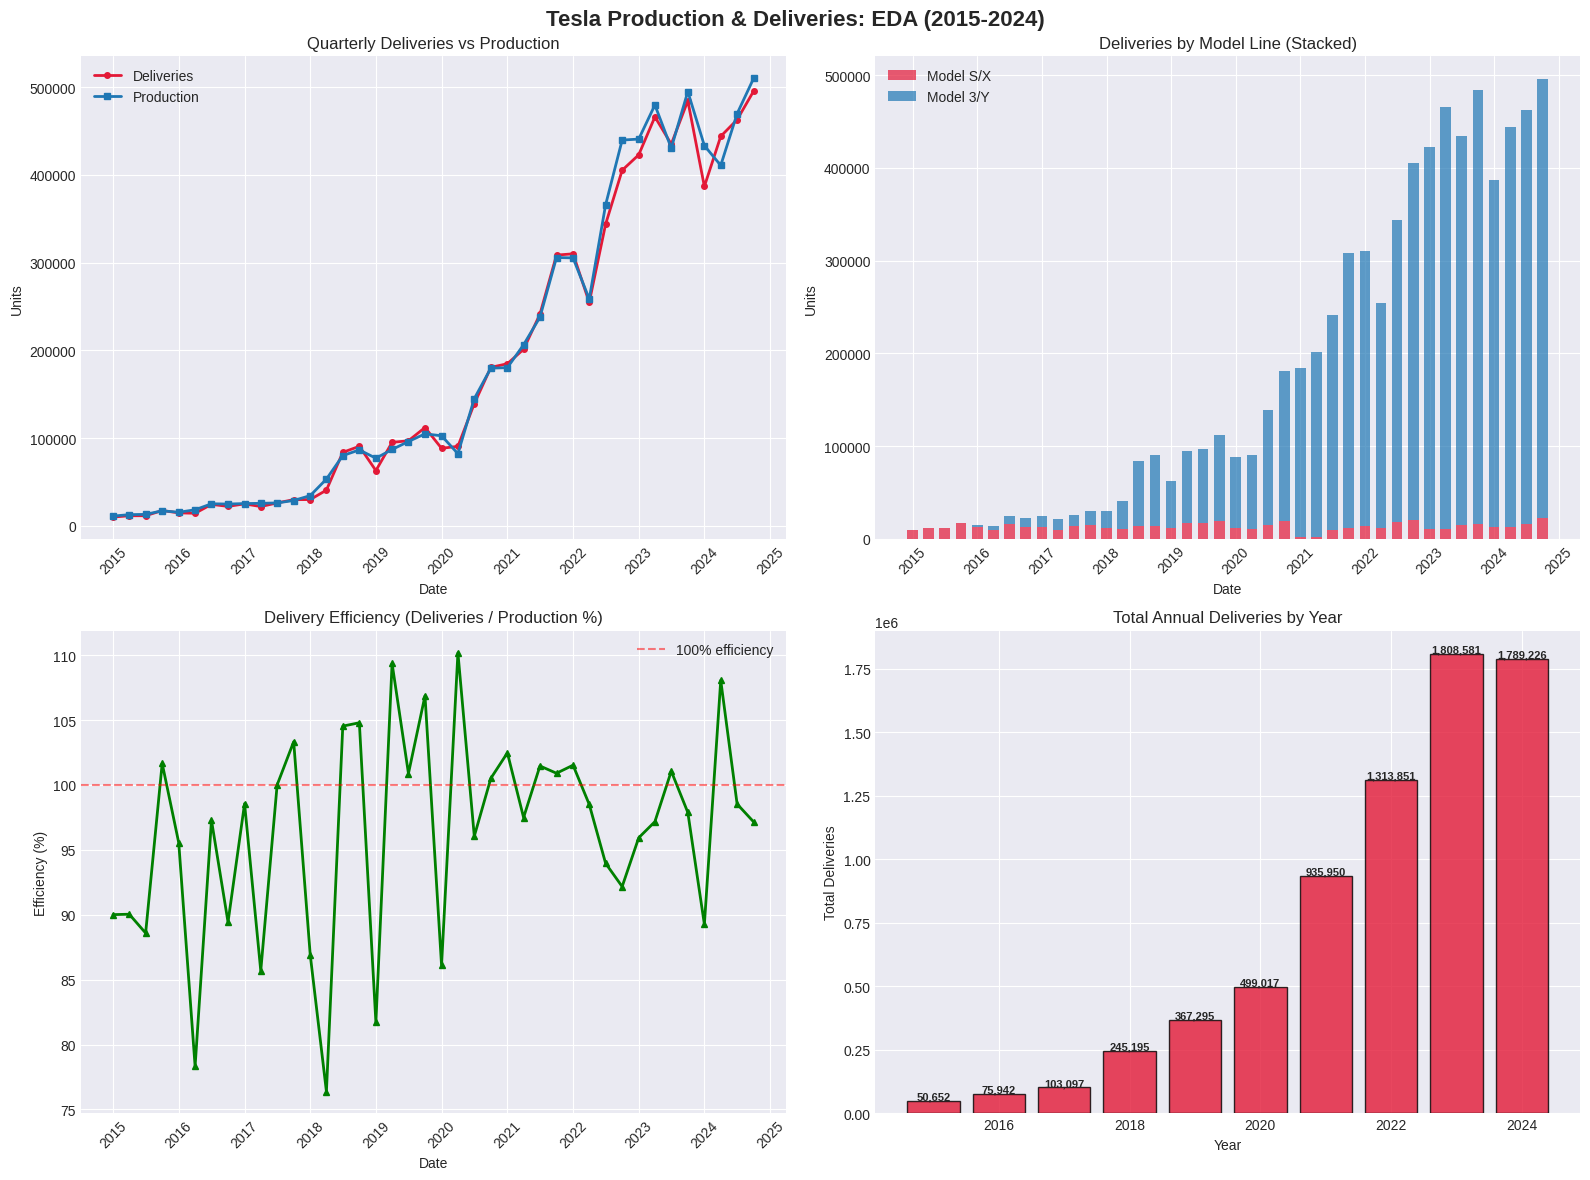

In [10]:
fig, axes=plt.subplots(2, 2, figsize=(16,12))  # create a 2x2 grid of 4 charts in one figure
fig.suptitle('Tesla Production & Deliveries: EDA (2015-2024)', fontsize=16, fontweight='bold')  # big title at top

# --- Chart 1: Deliveries vs Production line chart ---
ax1=axes[0,0]  # top-left chart slot
ax1.plot(df['Date'], df['Deliveries'], color='#E31937', linewidth=2, marker='o', markersize=4, label='Deliveries')  # red line for deliveries
ax1.plot(df['Date'], df['Production'], color='#1f77b4', linewidth=2, marker='s', markersize=4, label='Production')  # blue line for production
ax1.set_title('Quarterly Deliveries vs Production')  # chart title
ax1.set_xlabel('Date')  # x-axis label
ax1.set_ylabel('Units')  # y-axis label
ax1.legend()  # show the legend
ax1.tick_params(axis='x', rotation=45)  # rotate x labels 45 degrees to avoid overlap

# --- Chart 2: Stacked bar chart by model line ---
ax2=axes[0,1]  # top-right chart slot
ax2.bar(df['Date'], df['Model_S_X_Deliveries'], color='#E31937', alpha=0.7, label='Model S/X', width=60)  # red bars for S/X
ax2.bar(df['Date'], df['Model_3_Y_Deliveries'], bottom=df['Model_S_X_Deliveries'], color='#1f77b4', alpha=0.7, label='Model 3/Y', width=60)
# bottom= makes Model 3/Y bars start where Model S/X bars end (stacked)
ax2.set_title('Deliveries by Model Line (Stacked)')  # chart title
ax2.set_xlabel('Date')  # x-axis label
ax2.set_ylabel('Units')  # y-axis label
ax2.legend()  # show the legend
ax2.tick_params(axis='x', rotation=45)  # tilt x labels

# --- Chart 3: Delivery efficiency over time ---
ax3=axes[1,0]  # bottom-left chart slot
ax3.plot(df['Date'], df['Delivery_Efficiency'], color='green', linewidth=2, marker='^', markersize=4)  # green line
ax3.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100% efficiency')  # red dashed line at 100%
ax3.set_title('Delivery Efficiency (Deliveries / Production %)')  # chart title
ax3.set_xlabel('Date')  # x-axis label
ax3.set_ylabel('Efficiency (%)')  # y-axis label
ax3.legend()  # show legend
ax3.tick_params(axis='x', rotation=45)  # tilt x labels

# --- Chart 4: Total annual deliveries bar chart ---
ax4=axes[1,1]  # bottom-right chart slot
yearly=df.groupby('Year')['Deliveries'].sum().reset_index()  # sum deliveries for each year
ax4.bar(yearly['Year'], yearly['Deliveries'], color='#E31937', edgecolor='black', alpha=0.8)  # bar for each year
ax4.set_title('Total Annual Deliveries by Year')  # chart title
ax4.set_xlabel('Year')  # x-axis label
ax4.set_ylabel('Total Deliveries')  # y-axis label
for i, row in yearly.iterrows():  # loop through each year to add value labels on top of bars
    ax4.text(row['Year'], row['Deliveries']+5000, f"{row['Deliveries']:,}", ha='center', fontsize=8, fontweight='bold')
    # f"{value:,}" formats numbers with commas like 1,000,000 so they're easier to read

plt.tight_layout()  # automatically fix spacing so charts don't overlap
plt.show()  # display the figure

### 3.3 Correlation Heatmap

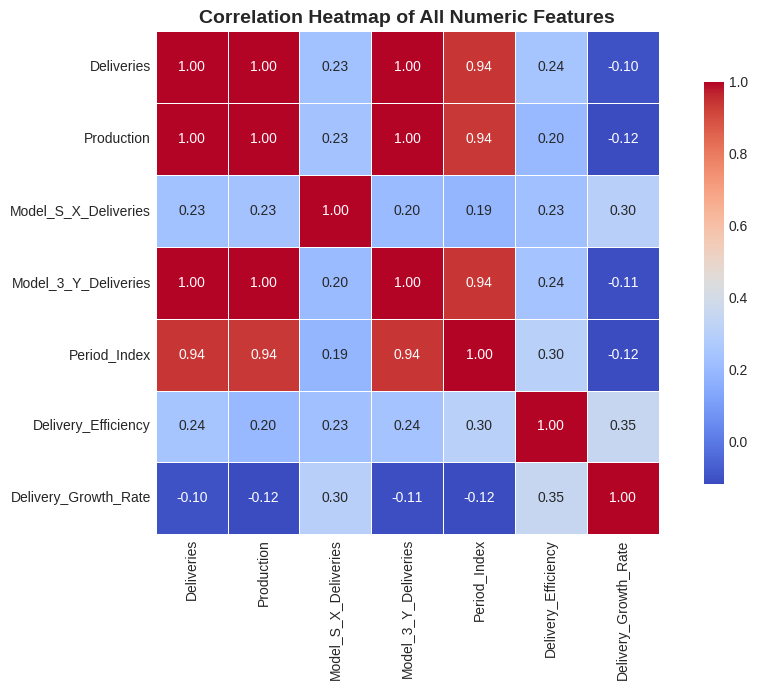

In [11]:
num_cols=['Deliveries','Production','Model_S_X_Deliveries','Model_3_Y_Deliveries',  # list of numeric columns
          'Period_Index','Delivery_Efficiency','Delivery_Growth_Rate']
corr_matrix=df[num_cols].corr()  # .corr() calculates correlation between every pair of columns (-1 to +1)

plt.figure(figsize=(10,7))  # set chart size
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',  # draw heatmap; annot=True shows numbers inside cells
            square=True, linewidths=0.5, cbar_kws={'shrink':0.8})  # square=True makes cells square shaped
plt.title('Correlation Heatmap of All Numeric Features', fontsize=14, fontweight='bold')  # chart title
plt.tight_layout()  # fix spacing
plt.show()  # display it

### 3.4 Distribution Plots

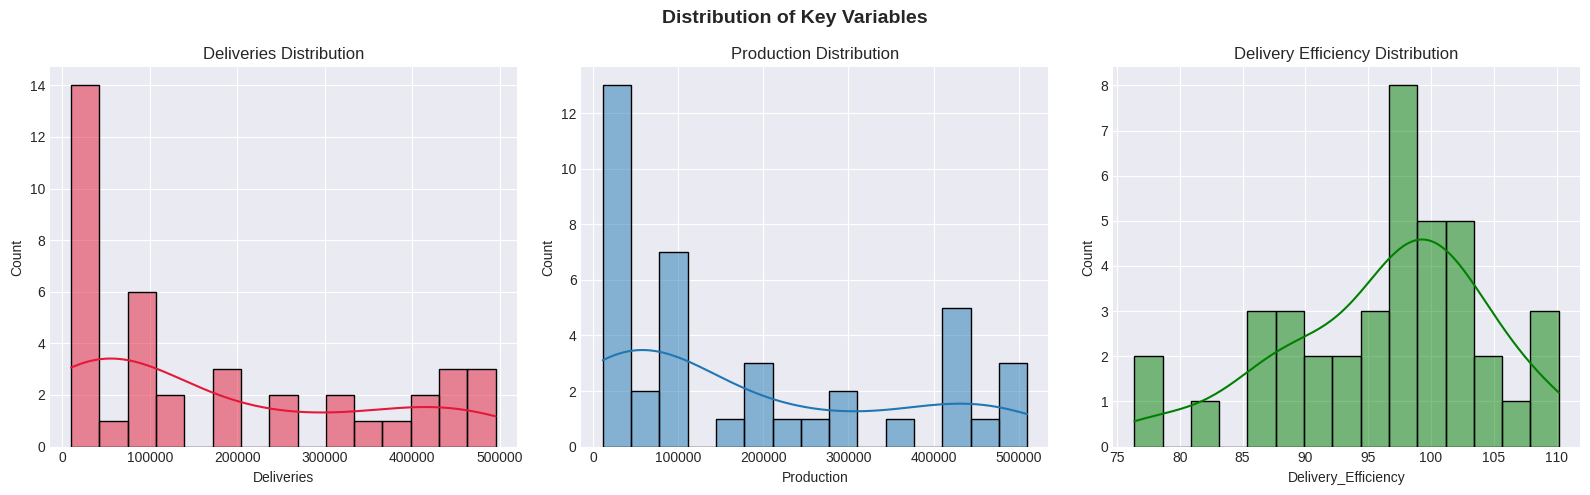

In [12]:
fig, axes=plt.subplots(1, 3, figsize=(16,5))  # 1 row of 3 charts side by side
fig.suptitle('Distribution of Key Variables', fontsize=14, fontweight='bold')  # big title

sns.histplot(df['Deliveries'], bins=15, ax=axes[0], color='#E31937', kde=True)  # histogram + smooth KDE curve
axes[0].set_title('Deliveries Distribution')  # label the first chart

sns.histplot(df['Production'], bins=15, ax=axes[1], color='#1f77b4', kde=True)  # histogram for production
axes[1].set_title('Production Distribution')  # label the second chart

sns.histplot(df['Delivery_Efficiency'], bins=15, ax=axes[2], color='green', kde=True)  # histogram for efficiency
axes[2].set_title('Delivery Efficiency Distribution')  # label the third chart

plt.tight_layout()  # fix spacing
plt.show()  # display it

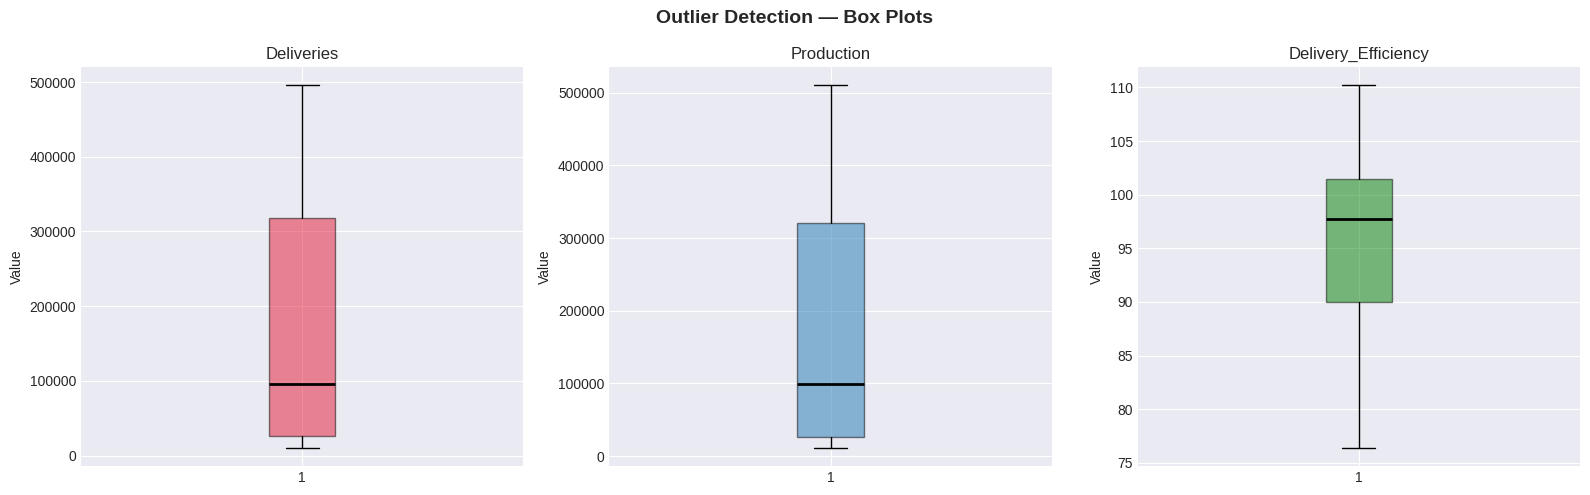

Potential outlier quarters (|z|>2.5): 0


In [13]:
# ── 3.5  Outlier Detection ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Outlier Detection — Box Plots', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes,
                           ['Deliveries', 'Production', 'Delivery_Efficiency'],
                           ['#E31937', '#1f77b4', 'green']):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.5),
                    medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{col}')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

# Z-score outlier flag
from scipy.stats import zscore
z_scores = df[['Deliveries','Production']].apply(zscore)
outlier_mask = (z_scores.abs() > 2.5).any(axis=1)
print(f"Potential outlier quarters (|z|>2.5): {outlier_mask.sum()}")
if outlier_mask.sum():
    print(df[outlier_mask][['Year','Quarter','Deliveries','Production']])


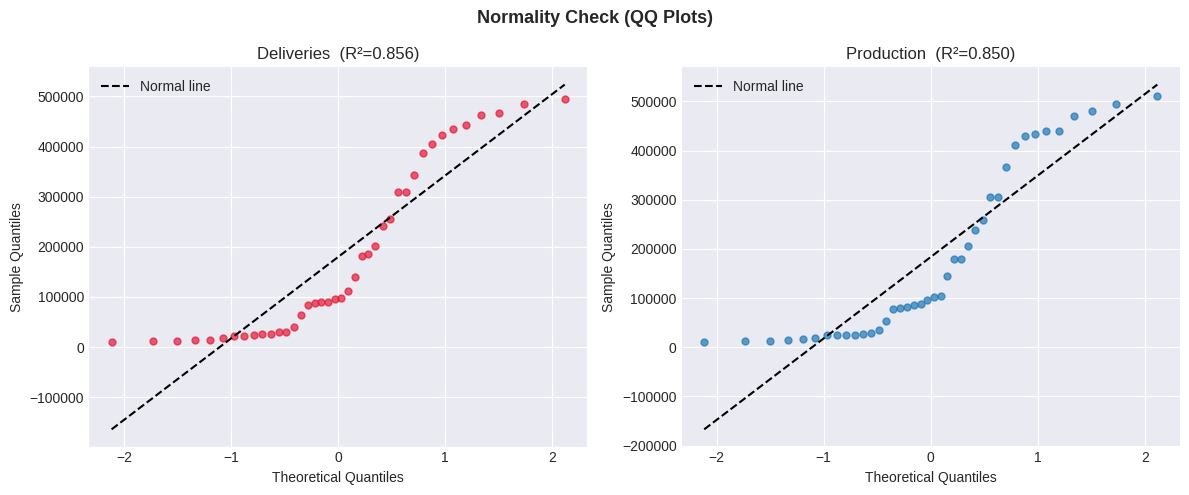

Shapiro-Wilk [Deliveries]: stat=0.8384  p=0.0000  → Non-normal ⚠️
Shapiro-Wilk [Production]: stat=0.8333  p=0.0000  → Non-normal ⚠️


In [14]:
# ── 3.6  Normality Check — QQ Plot ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Normality Check (QQ Plots)', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['Deliveries', 'Production'], ['#E31937', '#1f77b4']):
    (osm, osr), (slope, intercept, r) = stats.probplot(df[col], dist='norm')
    ax.plot(osm, osr, 'o', color=color, alpha=0.7, markersize=5)
    ax.plot(osm, slope*np.array(osm)+intercept, 'k--', linewidth=1.5, label='Normal line')
    ax.set_title(f'{col}  (R²={r**2:.3f})')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.legend()

plt.tight_layout()
plt.show()

# Shapiro-Wilk test
for col in ['Deliveries','Production']:
    stat, p = stats.shapiro(df[col])
    verdict = 'Normal ✅' if p > 0.05 else 'Non-normal ⚠️'
    print(f'Shapiro-Wilk [{col}]: stat={stat:.4f}  p={p:.4f}  → {verdict}')


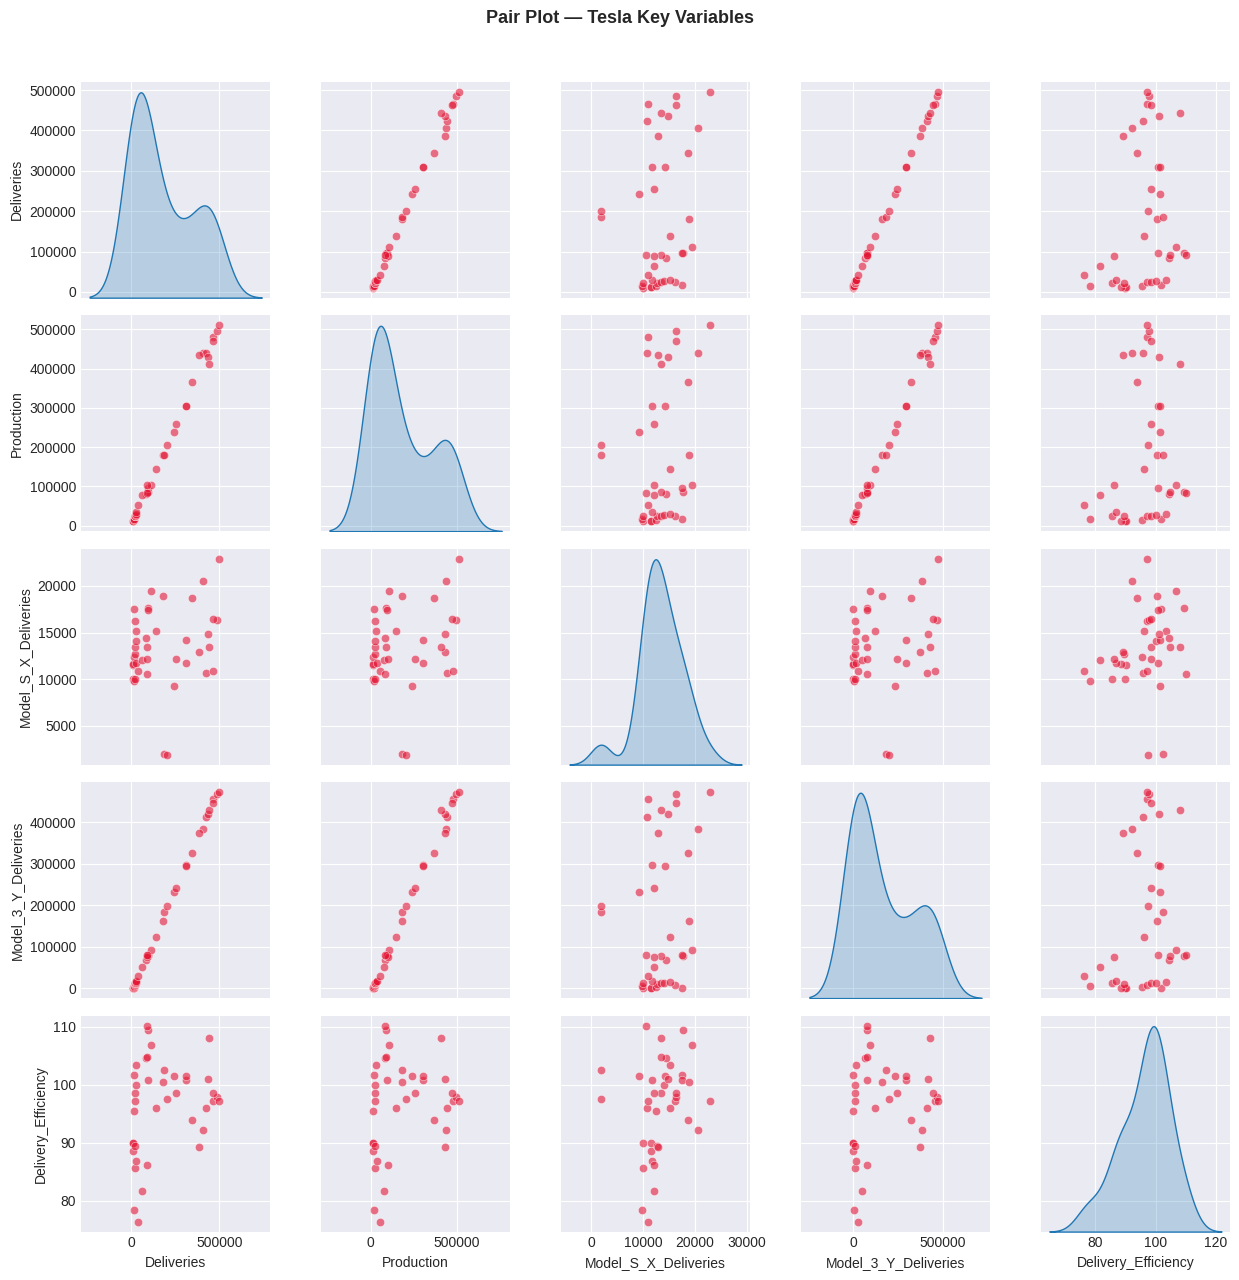

In [15]:
# ── 3.7  Pair Plot — Key Variables ─────────────────────────────────────────
pair_cols = ['Deliveries','Production','Model_S_X_Deliveries','Model_3_Y_Deliveries','Delivery_Efficiency']
pair_df = df[pair_cols].copy()

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha':0.6, 'color':'#E31937'},
                 diag_kws={'color':'#1f77b4'})
g.figure.suptitle('Pair Plot — Tesla Key Variables', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


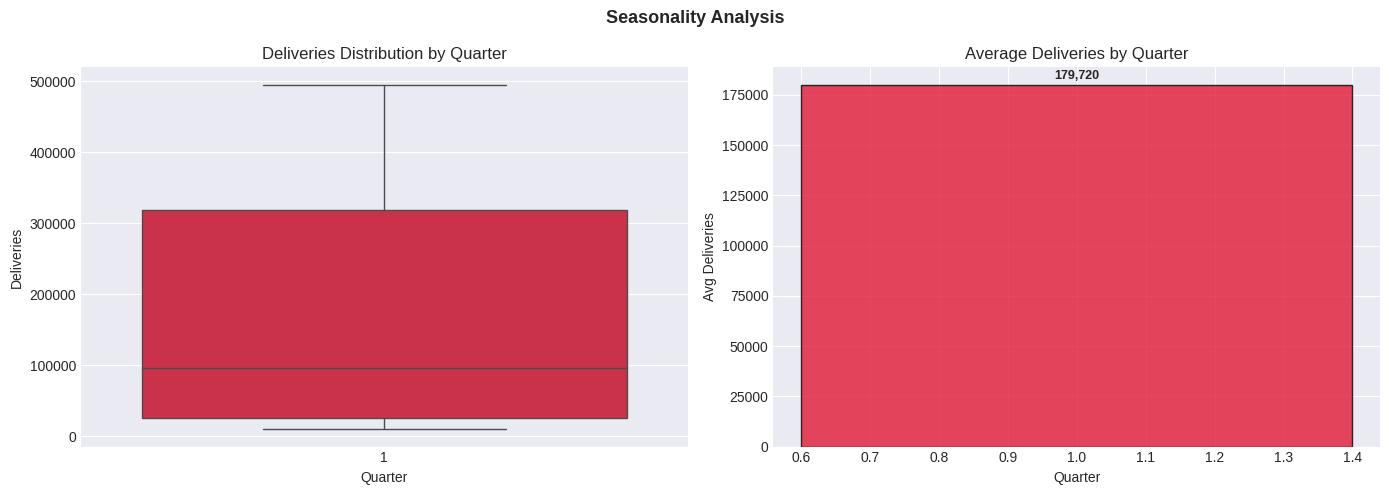

Key insight: Q4 typically has highest deliveries (Tesla's end-of-year push).


In [16]:
# ── 3.8  Seasonal Boxplot — Deliveries by Quarter ──────────────────────────
orig_df_with_quarter = df.copy()
# Recover Quarter from Q_ dummies (or use Period_Index mod 4)
# Q_2, Q_3, Q_4 are dummies; Q_1 = no flags set
def recover_quarter(row):
    for q in [2, 3, 4]:
        if row.get(f'Q_{q}', False):
            return q
    return 1
orig_df_with_quarter['Quarter_Num'] = orig_df_with_quarter.apply(recover_quarter, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seasonality Analysis', fontsize=13, fontweight='bold')

# Boxplot per quarter
sns.boxplot(x='Quarter_Num', y='Deliveries', data=orig_df_with_quarter,
            palette=['#E31937','#1f77b4','green','orange'], ax=axes[0])
axes[0].set_title('Deliveries Distribution by Quarter')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Deliveries')

# Mean delivery per quarter (bar)
q_means = orig_df_with_quarter.groupby('Quarter_Num')['Deliveries'].mean()
axes[1].bar(q_means.index, q_means.values,
            color=['#E31937','#1f77b4','green','orange'], edgecolor='black', alpha=0.8)
for q, v in q_means.items():
    axes[1].text(q, v+3000, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Deliveries by Quarter')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Avg Deliveries')

plt.tight_layout()
plt.show()
print("Key insight: Q4 typically has highest deliveries (Tesla's end-of-year push).")


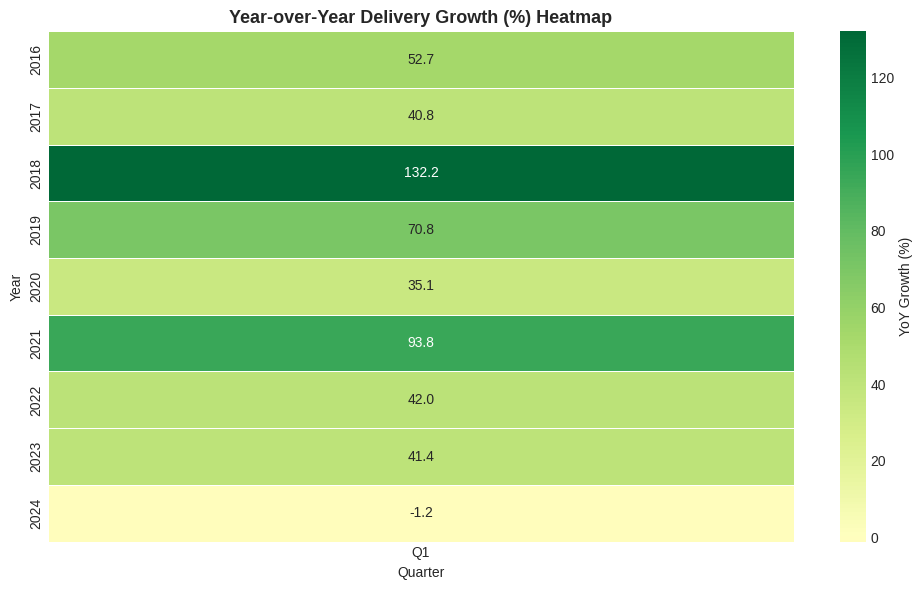

In [17]:
# ── 3.9  YoY Growth Heatmap ────────────────────────────────────────────────
# Rebuild year/quarter from Period_Index for heatmap
yoy_temp = df[['Period_Index','Deliveries','Date']].copy()
yoy_temp['Year']  = yoy_temp['Date'].dt.year
# Recover Quarter_Num from Q_ dummies
yoy_temp['Quarter_Num'] = yoy_temp.apply(recover_quarter, axis=1)
yoy_temp = yoy_temp.sort_values('Date')
yoy_temp['YoY_Growth_Pct'] = yoy_temp['Deliveries'].pct_change(periods=4) * 100

pivot = yoy_temp.pivot_table(index='Year', columns='Quarter_Num', values='YoY_Growth_Pct')
pivot.columns = [f'Q{c}' for c in pivot.columns]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'YoY Growth (%)'})
plt.title('Year-over-Year Delivery Growth (%) Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


### 3.5 Key EDA Insights

In [18]:
print('-- EDA Insights --')  # section header
print(f'Average quarterly deliveries : {df["Deliveries"].mean():,.0f}')  # average deliveries per quarter

peak_idx=df['Deliveries'].idxmax()  # find the row index of maximum deliveries
print(f'Peak quarter deliveries      : {df["Deliveries"].max():,} (Q{df.loc[peak_idx,"Quarter"]} {df.loc[peak_idx,"Year"]})')  # show which quarter

print(f'Average delivery efficiency  : {df["Delivery_Efficiency"].mean():.1f}%')  # mean efficiency across all quarters
print(f'Correlation (Time vs Deliveries): {df["Period_Index"].corr(df["Deliveries"]):.3f}')  # strong = steady growth over time

-- EDA Insights --
Average quarterly deliveries : 179,720
Peak quarter deliveries      : 495,570 (Q4 2024)
Average delivery efficiency  : 96.4%
Correlation (Time vs Deliveries): 0.941


---
## Part 4 — Feature Engineering

### 4.1 Create New Features

We create extra columns that give the model more information to learn from:
- **Lag features** — what happened last quarter and two quarters ago
- **Rolling averages** — smooth trend over last 2 and 4 quarters
- **YoY growth** — compare to the same quarter last year
- **Production gap** — difference between cars made and cars delivered
- **Model mix share** — what fraction are Model 3/Y
- **Quarter dummies** — one-hot encoding of the quarter number

In [19]:
df['Deliveries_Lag1']=df['Deliveries'].shift(1)  # shift deliveries column down 1 row = previous quarter's value
df['Deliveries_Lag2']=df['Deliveries'].shift(2)  # shift down 2 rows = two quarters ago value
df['Production_Lag1']=df['Production'].shift(1)  # previous quarter's production number
# lag features help the model learn: if deliveries were high last quarter, they may stay high

df['Rolling_Avg_4Q']=df['Deliveries'].rolling(window=4).mean()  # average deliveries over the last 4 quarters
df['Rolling_Avg_2Q']=df['Deliveries'].rolling(window=2).mean()  # average over the last 2 quarters (shorter trend)
# rolling averages smooth out random spikes so the model sees the general trend

df['YoY_Growth']=df['Deliveries'].pct_change(periods=4)*100  # compare to same quarter last year (4 rows back)
# Year-over-Year growth is a very important business metric for Tesla's performance

df['Production_Gap']=df['Production']-df['Deliveries']  # positive = more produced than delivered (building inventory)
# negative gap means Tesla delivered from previously built stock

df['Model_3Y_Share']=df['Model_3_Y_Deliveries']/df['Deliveries']*100  # % of deliveries that are Model 3 or Y
# this ratio shows how Tesla's product mix shifted from premium to mass market over the years

df=pd.get_dummies(df, columns=['Quarter'], prefix='Q', drop_first=True)  # convert Quarter 1/2/3/4 into Q_2, Q_3, Q_4 binary columns
# dummy variables let the model understand Q4 (holiday season) may behave differently from Q1

df=df.dropna()  # drop rows that have NaN (lag and rolling features create NaN at the start of the series)
df=df.reset_index(drop=True)  # reset row indices after dropping NaN rows

print(f'Features after engineering: {list(df.columns)}')  # show all column names including new ones
print(f'Dataset size after dropping NaN rows: {df.shape}')  # show updated shape

Features after engineering: ['Year', 'Deliveries', 'Production', 'Model_S_X_Deliveries', 'Model_3_Y_Deliveries', 'Date', 'Period_Index', 'Delivery_Growth_Rate', 'Production_Growth_Rate', 'Delivery_Efficiency', 'Deliveries_Lag1', 'Deliveries_Lag2', 'Production_Lag1', 'Rolling_Avg_4Q', 'Rolling_Avg_2Q', 'YoY_Growth', 'Production_Gap', 'Model_3Y_Share', 'Q_2', 'Q_3', 'Q_4']
Dataset size after dropping NaN rows: (36, 21)


---
## Part 5 — Regression Modeling

### 5.1 Prepare Features & Split Data

- **X** = all input columns the model uses to learn
- **y** = the target column we want to predict (Deliveries)
- We split into **80% training** and **20% testing**

In [20]:
feature_cols=[  # list of input columns the model will use to learn patterns
    'Production','Model_S_X_Deliveries','Model_3_Y_Deliveries',
    'Period_Index','Delivery_Efficiency','Deliveries_Lag1',
    'Deliveries_Lag2','Production_Lag1','Rolling_Avg_4Q',
    'YoY_Growth','Production_Gap','Model_3Y_Share',
]
q_cols=[c for c in df.columns if c.startswith('Q_')]  # grab all quarter dummy columns (Q_2, Q_3, Q_4)
feature_cols=feature_cols+q_cols  # combine main features with quarter dummies

X=df[feature_cols]  # X = all the input features
y=df['Deliveries']  # y = what we want to predict

X_train, X_test, y_train, y_test=train_test_split(  # split into training and testing sets
    X, y, test_size=0.2, random_state=42  # 80% train, 20% test; random_state=42 gives same split every run
)
print(f'Training samples : {len(X_train)}')  # how many rows for training
print(f'Testing samples  : {len(X_test)}')  # how many rows for testing

scaler=StandardScaler()  # StandardScaler makes all features have mean=0 and std=1
X_train_scaled=scaler.fit_transform(X_train)  # fit on training data then transform it
X_test_scaled=scaler.transform(X_test)  # transform test data using the SAME scaler (very important!)
# fitting the scaler on test data separately would leak test info into training

Training samples : 28
Testing samples  : 8


### 5.2 Train & Evaluate All Models

In [21]:
models={  # dictionary of model name → model object
    'Linear Regression': LinearRegression(),  # simplest model; fits a straight line through data
    'Ridge Regression': Ridge(alpha=1.0),  # linear regression with L2 penalty to prevent overfitting
    'Lasso Regression': Lasso(alpha=1.0),  # linear regression with L1 penalty; can shrink weights to zero
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),  # 100 decision trees averaged together
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),  # trees built one after another
}

results={}  # empty dictionary to store performance metrics for each model

for name, model in models.items():  # loop through each model
    if name in ['Linear Regression','Ridge Regression','Lasso Regression']:  # linear models need scaled features
        model.fit(X_train_scaled, y_train)  # train on scaled data
        preds=model.predict(X_test_scaled)  # predict on scaled test data
    else:
        model.fit(X_train, y_train)  # tree models work fine without scaling
        preds=model.predict(X_test)  # predict on unscaled test data

    mae=mean_absolute_error(y_test, preds)  # MAE = average absolute error between predicted and actual
    rmse=np.sqrt(mean_squared_error(y_test, preds))  # RMSE = penalizes big errors more than MAE
    r2=r2_score(y_test, preds)  # R² = 1.0 is perfect; 0 means no better than guessing the average
    results[name]={'MAE':mae,'RMSE':rmse,'R2':r2,'Predictions':preds}  # save metrics

    print(f'{name}:')  # print model name
    print(f'  MAE : {mae:,.0f} units')  # print mean absolute error
    print(f'  RMSE: {rmse:,.0f} units')  # print root mean squared error
    print(f'  R²  : {r2:.4f}')  # print R-squared
    print()  # blank line between models

Linear Regression:
  MAE : 0 units
  RMSE: 0 units
  R²  : 1.0000

Ridge Regression:
  MAE : 8,765 units
  RMSE: 10,848 units
  R²  : 0.9961

Lasso Regression:
  MAE : 420 units
  RMSE: 581 units
  R²  : 1.0000

Random Forest:
  MAE : 21,893 units
  RMSE: 28,910 units
  R²  : 0.9722

Gradient Boosting:
  MAE : 14,267 units
  RMSE: 17,977 units
  R²  : 0.9892



### 5.3 Model Comparison Chart

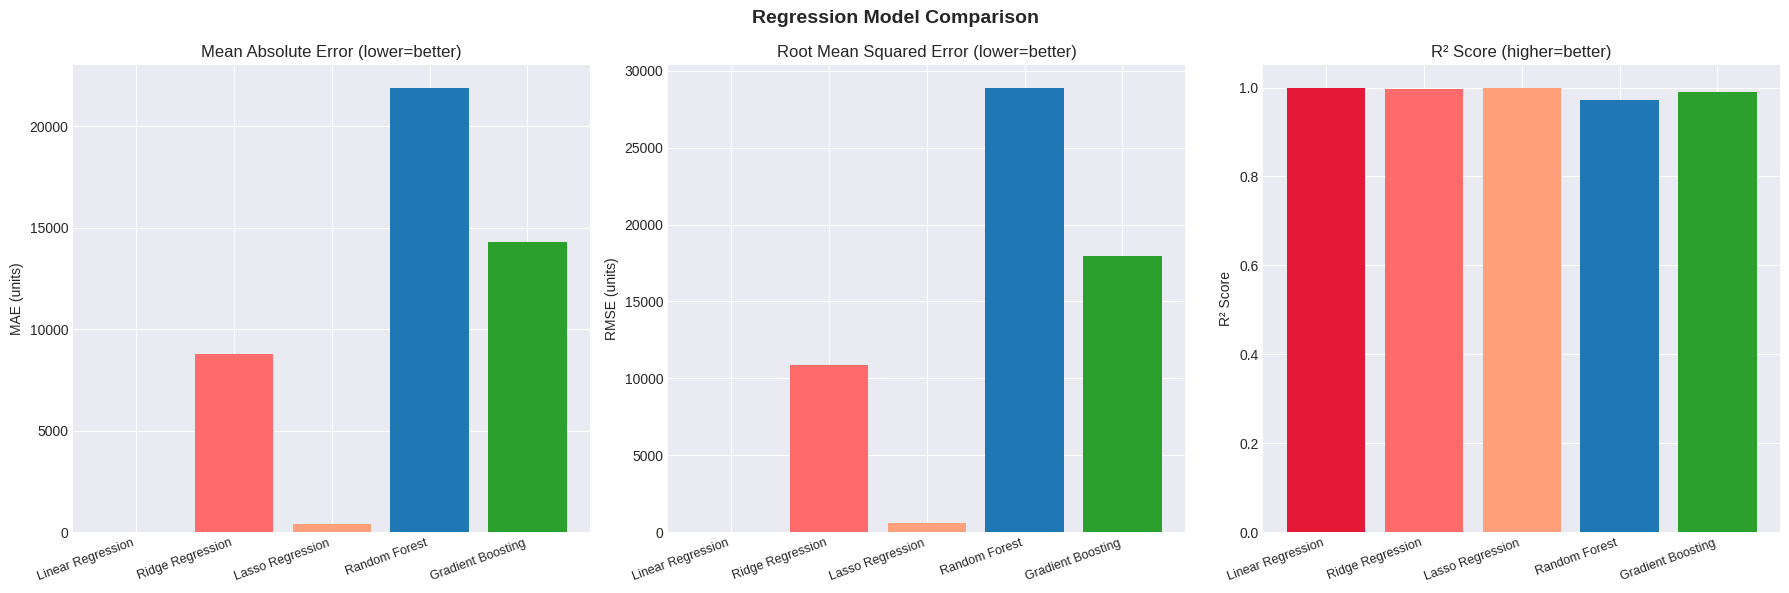

In [22]:
fig, axes=plt.subplots(1, 3, figsize=(18,6))  # 3 side-by-side charts
fig.suptitle('Regression Model Comparison', fontsize=14, fontweight='bold')  # overall title

model_names=list(results.keys())  # list of model names for x-axis
maes=[results[m]['MAE'] for m in model_names]  # MAE values for each model
rmses=[results[m]['RMSE'] for m in model_names]  # RMSE values for each model
r2s=[results[m]['R2'] for m in model_names]  # R2 values for each model
colors=['#E31937','#FF6B6B','#FFA07A','#1f77b4','#2ca02c']  # different color per model

axes[0].bar(model_names, maes, color=colors)  # bar chart of MAE
axes[0].set_title('Mean Absolute Error (lower=better)')  # title
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)  # rotated labels
axes[0].set_ylabel('MAE (units)')  # y-axis label

axes[1].bar(model_names, rmses, color=colors)  # bar chart of RMSE
axes[1].set_title('Root Mean Squared Error (lower=better)')  # title
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)  # rotated labels
axes[1].set_ylabel('RMSE (units)')  # y-axis label

axes[2].bar(model_names, r2s, color=colors)  # bar chart of R²
axes[2].set_title('R² Score (higher=better)')  # title
axes[2].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)  # rotated labels
axes[2].set_ylabel('R² Score')  # y-axis label
axes[2].set_ylim(0, 1.05)  # y-axis from 0 to slightly above 1

plt.tight_layout()  # fix spacing
plt.show()  # display

### 5.4 Actual vs Predicted Plot (Best Model)

Best model based on RMSE: Linear Regression


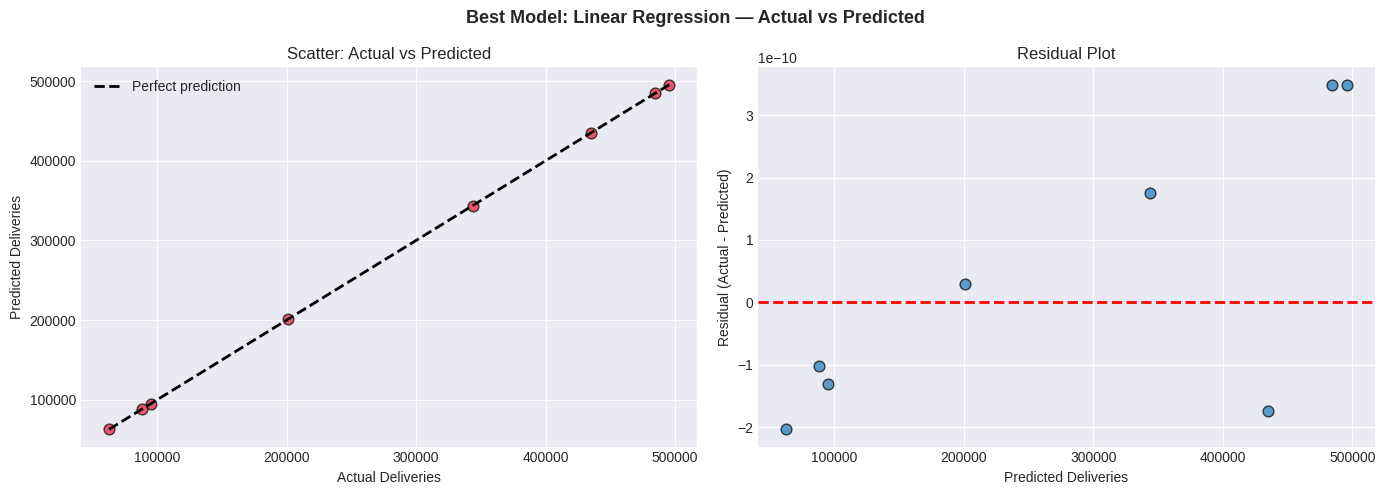

In [23]:
best_model_name=min(results, key=lambda x: results[x]['RMSE'])  # find model with lowest RMSE
print(f'Best model based on RMSE: {best_model_name}')  # tell the user which model won

best_preds=results[best_model_name]['Predictions']  # get predictions from the best model

fig, axes=plt.subplots(1, 2, figsize=(14,5))  # two charts side by side
fig.suptitle(f'Best Model: {best_model_name} — Actual vs Predicted', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, best_preds, color='#E31937', alpha=0.7, edgecolors='k', s=60)  # scatter plot
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect prediction')
# diagonal dashed line = where perfect predictions would fall
axes[0].set_xlabel('Actual Deliveries')  # x-axis
axes[0].set_ylabel('Predicted Deliveries')  # y-axis
axes[0].set_title('Scatter: Actual vs Predicted')  # title
axes[0].legend()  # legend

residuals=y_test.values-best_preds  # residuals = actual minus predicted
axes[1].scatter(best_preds, residuals, color='#1f77b4', alpha=0.7, edgecolors='k', s=60)  # residual plot
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)  # red line at zero (ideal: all residuals near zero)
axes[1].set_xlabel('Predicted Deliveries')  # x-axis
axes[1].set_ylabel('Residual (Actual - Predicted)')  # y-axis
axes[1].set_title('Residual Plot')  # title

plt.tight_layout()  # fix spacing
plt.show()  # display

### 5.5 Additional Models: ElasticNet, Polynomial Ridge, XGBoost
We extend the comparison with regularised and boosted models for a more thorough benchmark.

In [24]:
# ── 5.5  Additional Models: ElasticNet, Polynomial Ridge, XGBoost ───────────

extra_results = {}

# --- ElasticNet ---
en = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000, random_state=42)
en.fit(X_train_scaled, y_train)
en_preds = en.predict(X_test_scaled)
extra_results['ElasticNet'] = {
    'MAE':  mean_absolute_error(y_test, en_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, en_preds)),
    'R2':   r2_score(y_test, en_preds),
    'Predictions': en_preds
}

# --- Polynomial (degree=2) Ridge ---
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10.0))
])
poly_pipe.fit(X_train, y_train)
poly_preds = poly_pipe.predict(X_test)
extra_results['Poly Ridge (deg=2)'] = {
    'MAE':  mean_absolute_error(y_test, poly_preds),
    'RMSE': np.sqrt(mean_squared_error(y_test, poly_preds)),
    'R2':   r2_score(y_test, poly_preds),
    'Predictions': poly_preds
}

# --- XGBoost or fallback ---
if XGBOOST_AVAILABLE:
    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                       subsample=0.8, random_state=42, verbosity=0)
    xgb.fit(X_train, y_train)
    xgb_preds = xgb.predict(X_test)
    extra_results['XGBoost'] = {
        'MAE':  mean_absolute_error(y_test, xgb_preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, xgb_preds)),
        'R2':   r2_score(y_test, xgb_preds),
        'Predictions': xgb_preds
    }

print("Extra model results:")
for name, res in extra_results.items():
    print(f"  {name:<22} MAE={res['MAE']:>9,.0f}  RMSE={res['RMSE']:>9,.0f}  R²={res['R2']:.4f}")

# Merge with main results for subsequent plots
results.update(extra_results)


Extra model results:
  ElasticNet             MAE=   22,115  RMSE=   25,438  R²=0.9785
  Poly Ridge (deg=2)     MAE=   31,611  RMSE=   38,045  R²=0.9518
  XGBoost                MAE=   18,066  RMSE=   20,742  R²=0.9857


---
## Part 6 — Hyperparameter Tuning

### 6.1 GridSearchCV on Random Forest

GridSearchCV tries **every combination** of parameters we give it and picks the best one using cross-validation.

In [25]:
rf_param_grid={  # parameters and their possible values to try
    'n_estimators': [50, 100, 200],  # number of trees; more = slower but usually better
    'max_depth': [None, 5, 10, 15],  # how deep each tree can grow; None = unlimited
    'min_samples_split': [2, 5, 10],  # min samples needed to split a node; higher = simpler trees
}

rf_grid=GridSearchCV(  # try every combination of parameters above
    RandomForestRegressor(random_state=42),  # base model to tune
    rf_param_grid,  # the grid of parameters
    cv=5,  # 5-fold cross-validation: split training into 5 parts, train on 4, test on 1, repeat 5 times
    scoring='neg_mean_squared_error',  # negative MSE because GridSearchCV maximizes score
    n_jobs=-1,  # use all CPU cores to speed up the search
    verbose=0  # 0 = don't print each combination (would be too much output)
)

rf_grid.fit(X_train, y_train)  # run the grid search on training data
best_rf=rf_grid.best_estimator_  # extract the model with best found parameters
best_params=rf_grid.best_params_  # dictionary of best parameter values

print(f'Best Random Forest parameters: {best_params}')  # show winning combination

tuned_preds=best_rf.predict(X_test)  # predict with the tuned model
tuned_mae=mean_absolute_error(y_test, tuned_preds)  # calculate MAE
tuned_rmse=np.sqrt(mean_squared_error(y_test, tuned_preds))  # calculate RMSE
tuned_r2=r2_score(y_test, tuned_preds)  # calculate R²

print(f'\nTuned Random Forest Performance:')
print(f'  MAE : {tuned_mae:,.0f} units')
print(f'  RMSE: {tuned_rmse:,.0f} units')
print(f'  R²  : {tuned_r2:.4f}')

orig_rmse=results['Random Forest']['RMSE']  # original RF RMSE before tuning
improvement=(orig_rmse-tuned_rmse)/orig_rmse*100  # % improvement
print(f'\nRMSE improvement after tuning: {improvement:.1f}%')  # how much better after tuning

Best Random Forest parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Random Forest Performance:
  MAE : 21,432 units
  RMSE: 27,533 units
  R²  : 0.9748

RMSE improvement after tuning: 4.8%


### 6.2 Feature Importance

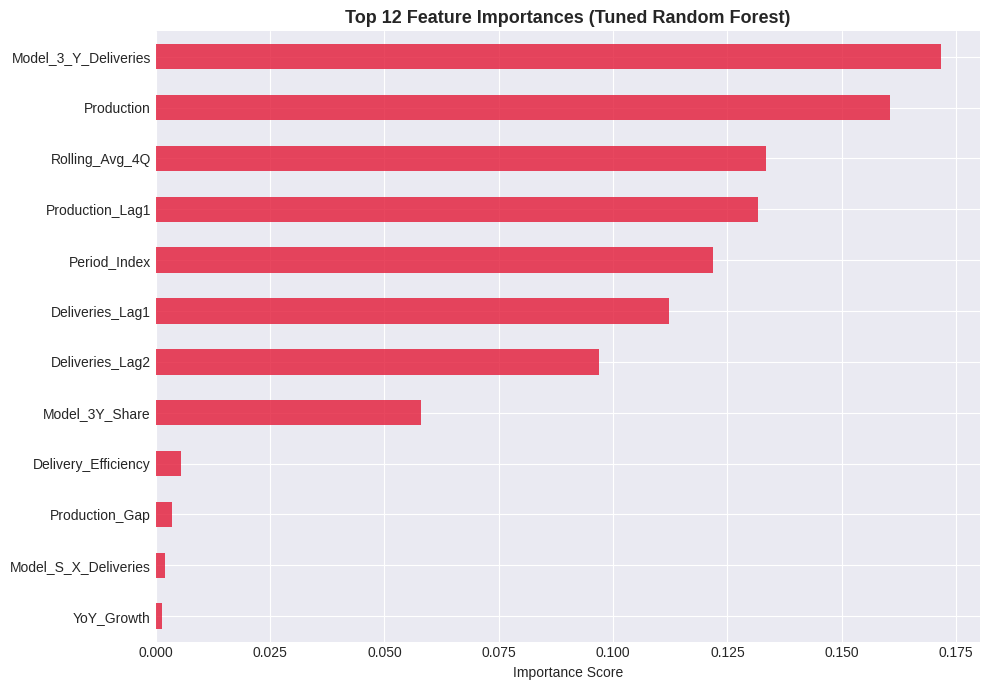

In [26]:
feat_importance=pd.Series(  # create a Series of feature names and importance scores
    best_rf.feature_importances_,  # how much each feature reduced prediction errors in the forest
    index=feature_cols  # use feature column names as the index
).sort_values(ascending=False)  # sort so most important is at the top

plt.figure(figsize=(10,7))  # set chart size
feat_importance.head(12).plot(kind='barh', color='#E31937', alpha=0.8)  # horizontal bar chart of top 12
plt.title('Top 12 Feature Importances (Tuned Random Forest)', fontsize=13, fontweight='bold')  # title
plt.xlabel('Importance Score')  # x-axis label
plt.gca().invert_yaxis()  # flip so most important is at the top
plt.tight_layout()  # fix spacing
plt.show()  # display

### 6.3 Cross-Validation & Ridge Tuning

In [27]:
cv_scores=cross_val_score(  # test model on 5 different subsets of data
    best_rf, X, y,  # use full dataset for more reliable CV
    cv=5,  # 5-fold
    scoring='neg_mean_squared_error'  # negative MSE scoring
)
cv_rmse=np.sqrt(-cv_scores)  # convert negative MSE back to positive RMSE
print(f'5-Fold CV RMSE scores: {[f"{v:,.0f}" for v in cv_rmse]}')  # all 5 fold scores
print(f'Mean CV RMSE : {cv_rmse.mean():,.0f} ± {cv_rmse.std():,.0f} units')  # mean and standard deviation
# small std means model is consistent across different subsets (not overfit)

# also tune Ridge alpha using GridSearch
ridge_param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}  # different alpha values to try
ridge_grid=GridSearchCV(Ridge(), ridge_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)  # fit on scaled data
print(f'\nBest Ridge alpha: {ridge_grid.best_params_["alpha"]}')  # best alpha found
tuned_ridge_r2=r2_score(y_test, ridge_grid.best_estimator_.predict(X_test_scaled))  # R² of tuned Ridge
print(f'Tuned Ridge R² : {tuned_ridge_r2:.4f}')  # print it

5-Fold CV RMSE scores: ['23,993', '17,832', '36,292', '41,175', '76,174']
Mean CV RMSE : 39,093 ± 20,333 units

Best Ridge alpha: 0.01
Tuned Ridge R² : 1.0000


### 6.4 Learning Curves
Learning curves reveal bias–variance trade-offs by plotting train vs. validation error as training size grows.

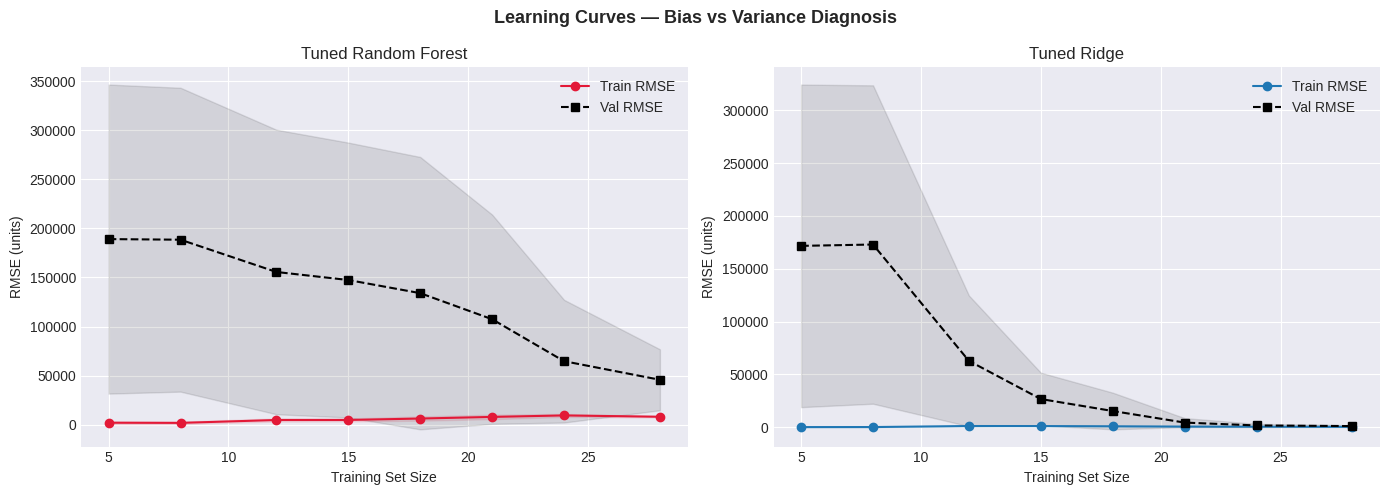

Tip: Converging train/val curves = well-fit model; large gap = overfitting.


In [28]:
# ── 6.4  Learning Curves — Bias–Variance Diagnosis ─────────────────────────
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Bias vs Variance Diagnosis', fontsize=13, fontweight='bold')

for ax, (model_obj, label, color) in zip(axes, [
        (best_rf,          'Tuned Random Forest',  '#E31937'),
        (ridge_grid.best_estimator_, 'Tuned Ridge', '#1f77b4'),
]):
    use_scaled = isinstance(model_obj, Ridge)
    Xu = X_train_scaled if use_scaled else X_train

    train_sizes, train_scores, val_scores = learning_curve(
        model_obj, X if not use_scaled else scaler.transform(X), y,
        cv=5, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.2, 1.0, 8), n_jobs=-1
    )
    train_rmse = np.sqrt(-train_scores)
    val_rmse   = np.sqrt(-val_scores)

    ax.plot(train_sizes, train_rmse.mean(axis=1), 'o-', color=color,   label='Train RMSE')
    ax.plot(train_sizes, val_rmse.mean(axis=1),   's--', color='black', label='Val RMSE')
    ax.fill_between(train_sizes,
                    train_rmse.mean(axis=1) - train_rmse.std(axis=1),
                    train_rmse.mean(axis=1) + train_rmse.std(axis=1),
                    alpha=0.1, color=color)
    ax.fill_between(train_sizes,
                    val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                    val_rmse.mean(axis=1) + val_rmse.std(axis=1),
                    alpha=0.1, color='black')
    ax.set_title(label)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('RMSE (units)')
    ax.legend()

plt.tight_layout()
plt.show()
print("Tip: Converging train/val curves = well-fit model; large gap = overfitting.")


### 6.5 Permutation Importance
Unlike Gini importance, permutation importance is model-agnostic and handles correlated features better.

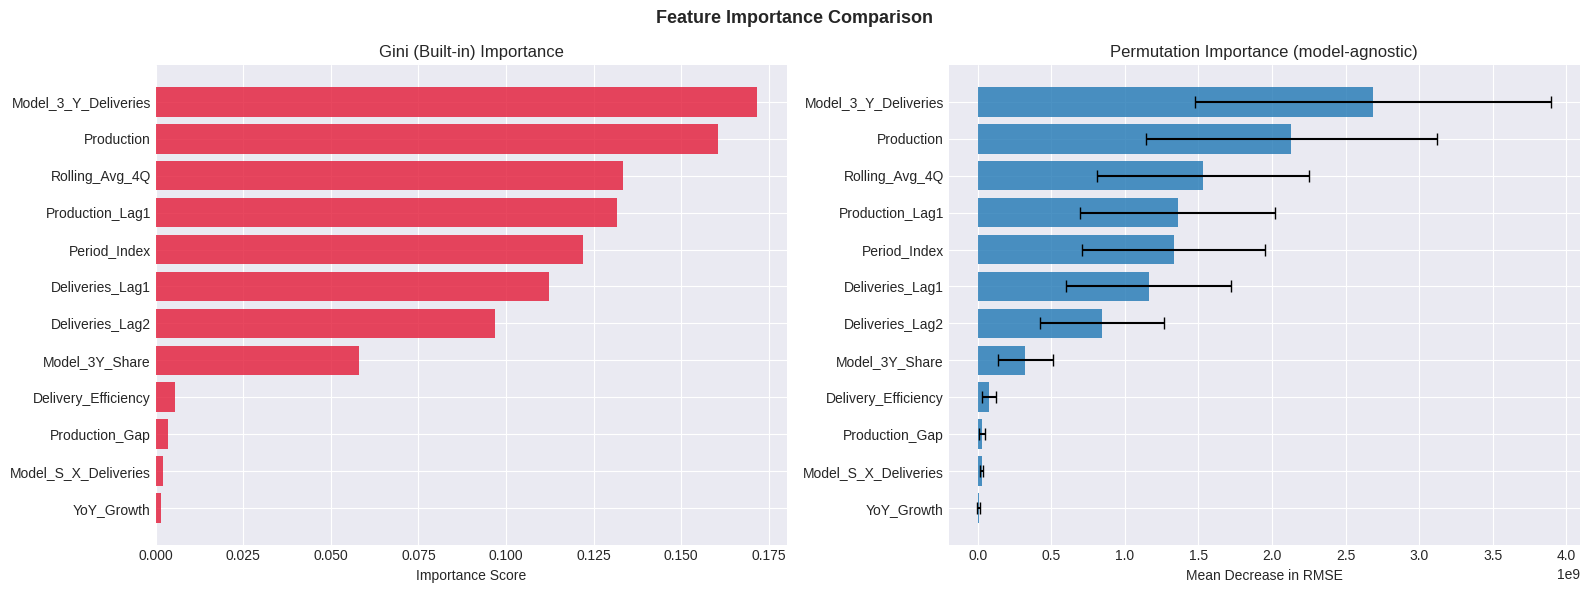

Permutation importance is more reliable than Gini for correlated features.


In [29]:
# ── 6.5  Permutation Importance (Model-Agnostic) ───────────────────────────
perm_result = permutation_importance(best_rf, X_test, y_test,
                                     n_repeats=20, random_state=42,
                                     scoring='neg_mean_squared_error')

perm_df = pd.DataFrame({
    'Feature':   feature_cols,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std
}).sort_values('Importance', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold')

# Gini (built-in) importance
feat_df = pd.DataFrame({'Feature': feature_cols,
                         'Gini_Importance': best_rf.feature_importances_}
                       ).sort_values('Gini_Importance', ascending=False).head(12)
axes[0].barh(feat_df['Feature'][::-1], feat_df['Gini_Importance'][::-1],
             color='#E31937', alpha=0.8)
axes[0].set_title('Gini (Built-in) Importance')
axes[0].set_xlabel('Importance Score')

# Permutation importance
axes[1].barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
             xerr=perm_df['Std'][::-1], color='#1f77b4', alpha=0.8,
             capsize=4)
axes[1].set_title('Permutation Importance (model-agnostic)')
axes[1].set_xlabel('Mean Decrease in RMSE')

plt.tight_layout()
plt.show()
print("Permutation importance is more reliable than Gini for correlated features.")


### 6.6 Cross-Validation RMSE Comparison
A fair comparison of all models using 5-fold CV on the full dataset.

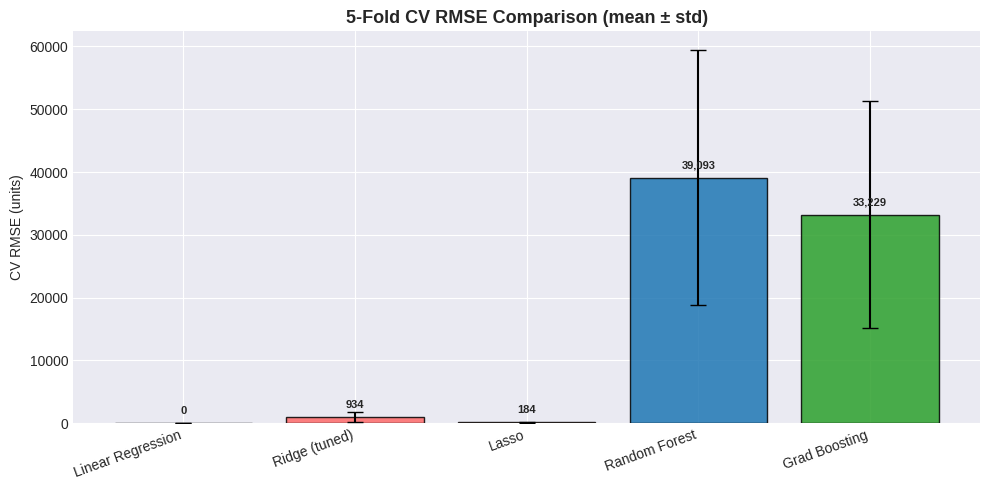

In [30]:
# ── 6.6  Cross-Validation RMSE Comparison (All Models) ─────────────────────
cv_summary = {}
for name, model_obj in [
    ('Linear Regression',  LinearRegression()),
    ('Ridge (tuned)',       ridge_grid.best_estimator_),
    ('Lasso',              Lasso(alpha=1.0)),
    ('Random Forest',      best_rf),
    ('Grad Boosting',      GradientBoostingRegressor(n_estimators=100, random_state=42)),
]:
    use_sc = name in ['Linear Regression', 'Ridge (tuned)', 'Lasso']
    Xu = scaler.transform(X) if use_sc else X
    cv_sc = cross_val_score(model_obj, Xu, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    cv_summary[name] = np.sqrt(-cv_sc)

cv_means = {k: v.mean() for k, v in cv_summary.items()}
cv_stds  = {k: v.std()  for k, v in cv_summary.items()}

fig, ax = plt.subplots(figsize=(10, 5))
names = list(cv_means.keys())
means = [cv_means[n] for n in names]
stds  = [cv_stds[n]  for n in names]
colors_cv = ['#E31937','#FF6B6B','#FFA07A','#1f77b4','#2ca02c']
bars = ax.bar(names, means, yerr=stds, capsize=6,
              color=colors_cv, edgecolor='black', alpha=0.85)
ax.set_title('5-Fold CV RMSE Comparison (mean ± std)', fontsize=13, fontweight='bold')
ax.set_ylabel('CV RMSE (units)')
ax.set_xticklabels(names, rotation=20, ha='right')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{m:,.0f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Part 7 — Time Series Forecasting

### 7.1 Prepare Time Series & Stationarity Test

The **ADF (Augmented Dickey-Fuller) test** checks if the series is **stationary** — meaning its mean and variance don't change over time. ARIMA models work best on stationary data.

In [31]:
ts=df.set_index('Date')['Deliveries']  # set Date as index and keep only Deliveries column
ts=ts.sort_index()  # sort by date just in case rows are out of order
ts.index.freq=None  # remove frequency attribute to avoid pandas warnings with quarterly data

print(f'Time series length: {len(ts)} quarters')  # how many data points
print(f'Time range: {ts.index.min().date()} to {ts.index.max().date()}')  # start and end dates

adf_result=adfuller(ts)  # ADF test: checks if series is stationary
print(f'\nADF Test statistic: {adf_result[0]:.4f}')  # more negative = more likely stationary
print(f'ADF p-value       : {adf_result[1]:.4f}')  # p-value < 0.05 means stationary
if adf_result[1] < 0.05:  # check if stationary
    print('→ Series is STATIONARY (good for ARIMA)')  # stationary means stable patterns over time
else:
    print('→ Series is NOT stationary (differencing may help)')  # non-stationary needs transformation

Time series length: 36 quarters
Time range: 2016-01-01 to 2024-10-01

ADF Test statistic: 0.1875
ADF p-value       : 0.9716
→ Series is NOT stationary (differencing may help)


### 7.1b ACF & PACF
ACF and PACF plots help identify the AR and MA orders for ARIMA modelling.

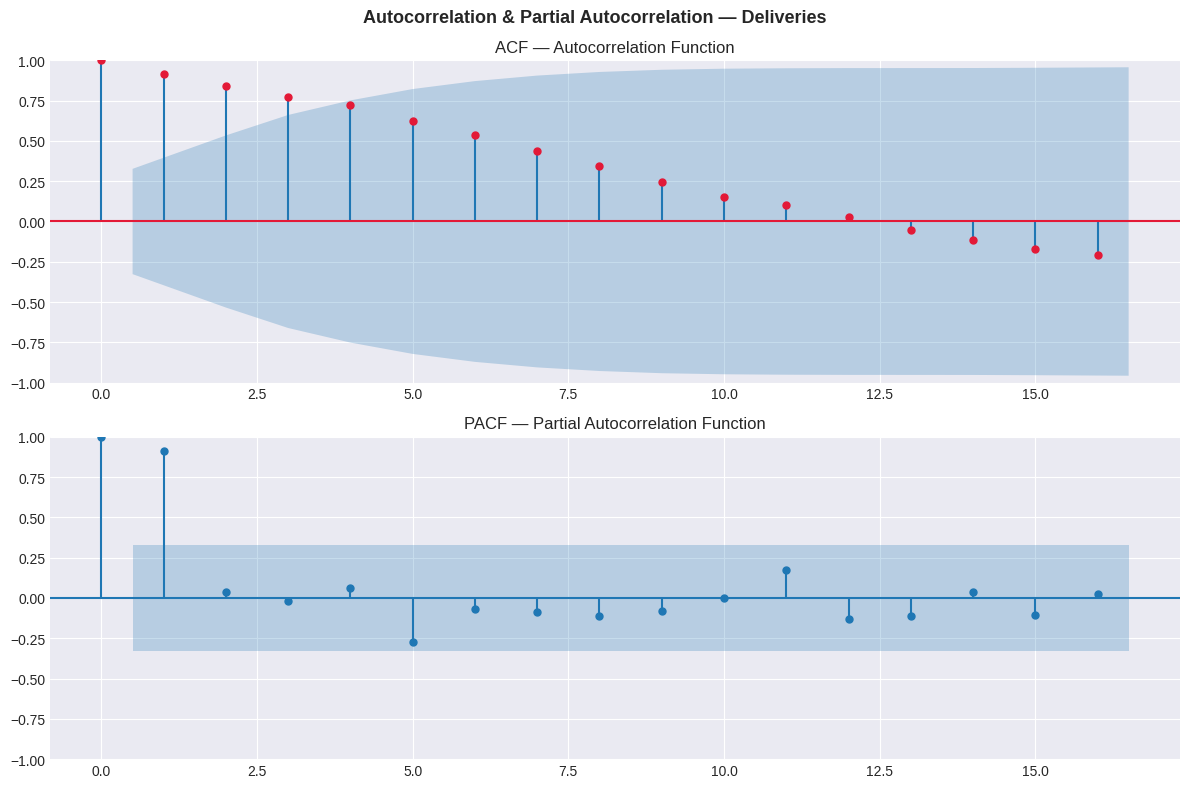

ACF/PACF helps choose ARIMA (p,d,q) orders.
Significant spikes at lag-4 would confirm quarterly seasonality.


In [32]:
# ── 7.1b  ACF & PACF Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Autocorrelation & Partial Autocorrelation — Deliveries', fontsize=13, fontweight='bold')

plot_acf(ts, lags=16, ax=axes[0], color='#E31937')
axes[0].set_title('ACF — Autocorrelation Function')

plot_pacf(ts, lags=16, ax=axes[1], color='#1f77b4', method='ywm')
axes[1].set_title('PACF — Partial Autocorrelation Function')

plt.tight_layout()
plt.show()
print("ACF/PACF helps choose ARIMA (p,d,q) orders.")
print("Significant spikes at lag-4 would confirm quarterly seasonality.")


### 7.1c Seasonal Decomposition
Decomposes the series into trend, seasonal cycle, and residual components.

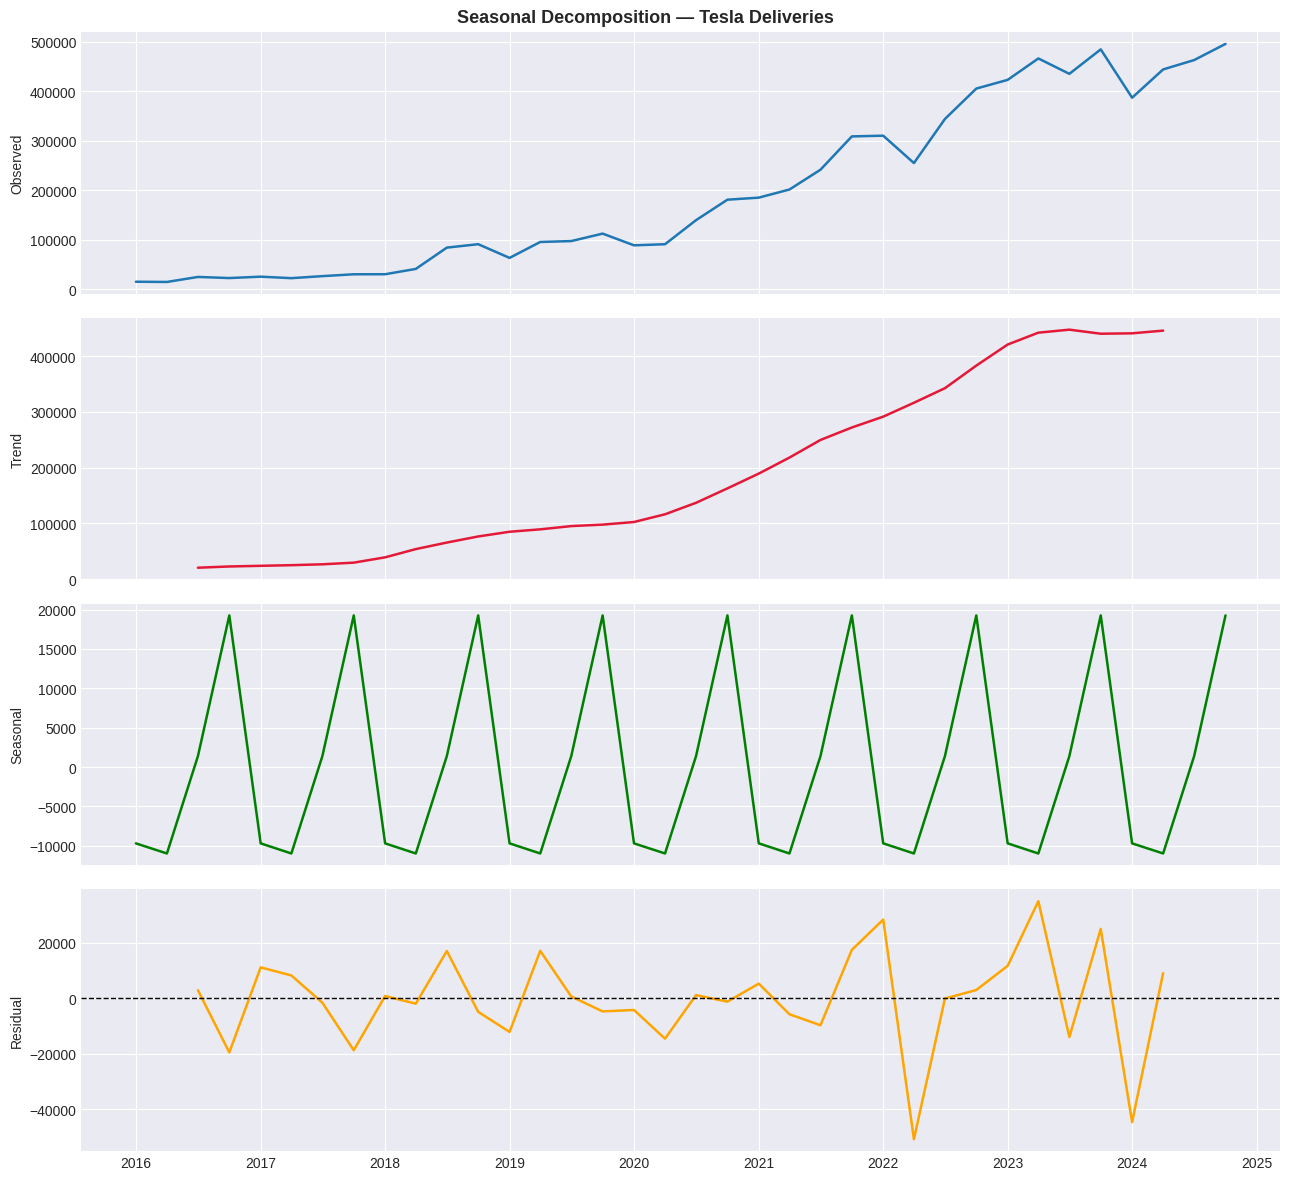

Upward trend is clear; residuals should be near-zero with no pattern.


In [33]:
# ── 7.1c  Classical Seasonal Decomposition ─────────────────────────────────
ts_filled = ts.copy()
ts_filled.index = pd.date_range(start=ts.index[0], periods=len(ts), freq='QS')

decomp = seasonal_decompose(ts_filled, model='additive', period=4)

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
fig.suptitle('Seasonal Decomposition — Tesla Deliveries', fontsize=13, fontweight='bold')

components = [
    (ts_filled,         'Observed',  '#1f77b4'),
    (decomp.trend,      'Trend',     '#E31937'),
    (decomp.seasonal,   'Seasonal',  'green'),
    (decomp.resid,      'Residual',  'orange'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1.8)
    ax.set_ylabel(title, fontsize=10)
    if title == 'Residual':
        ax.axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()
print("Upward trend is clear; residuals should be near-zero with no pattern.")


### 7.2 Holt-Winters Exponential Smoothing

In [34]:
n_forecast=6  # forecast 6 quarters into the future

hw_model=ExponentialSmoothing(  # Holt-Winters handles both trend and seasonality
    ts,  # historical delivery data
    trend='add',  # additive trend: assumes trend increases by a fixed amount each period
    seasonal='add',  # additive seasonality: seasonal effects are added on top of trend
    seasonal_periods=4,  # 4 quarters per year = seasonal cycle length
    initialization_method='estimated'  # let the model estimate starting values automatically
)
hw_fit=hw_model.fit(optimized=True)  # fit the model; optimized=True finds best smoothing parameters automatically
hw_forecast=hw_fit.forecast(n_forecast)  # generate 6 future forecasts

print('Holt-Winters forecast for next 6 quarters:')  # section header
for d, v in zip(hw_forecast.index, hw_forecast.values):  # loop through each forecast
    print(f'  {str(d.date())} : {int(v):,} deliveries')  # print date and forecast value

Holt-Winters forecast for next 6 quarters:
  2025-01-01 : 474,338 deliveries
  2025-04-01 : 484,481 deliveries
  2025-07-01 : 503,486 deliveries
  2025-10-01 : 534,284 deliveries
  2026-01-01 : 513,672 deliveries
  2026-04-01 : 523,815 deliveries


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


### 7.3 SARIMA Model (Auto Grid Search)

In [35]:
# SARIMA = Seasonal AutoRegressive Integrated Moving Average
# We try different combinations of parameters and pick the one with lowest AIC
p_vals=[0,1]  # AR order: how many past values to use
d_vals=[0,1]  # Integration order: how many times to difference the series
q_vals=[0,1]  # MA order: how many past errors to use
P_vals=[0,1]  # Seasonal AR order
D_vals=[0,1]  # Seasonal differencing order
Q_vals=[0,1]  # Seasonal MA order

best_aic=np.inf  # start with infinity so any model will beat it
best_sarima_params=None  # will store best parameter combination
best_sarima_model=None  # will store best fitted model

print('Searching best SARIMA parameters (this may take ~30 seconds)...')  # user feedback

for p,d,q,P,D,Q in itertools.product(p_vals,d_vals,q_vals,P_vals,D_vals,Q_vals):  # every combination
    try:  # some combinations cause math errors, so we catch and skip them
        sarima=SARIMAX(
            ts,  # the time series
            order=(p,d,q),  # non-seasonal part
            seasonal_order=(P,D,Q,4),  # seasonal part; 4 = quarters per year
            enforce_stationarity=False,  # don't force; avoids errors for non-stationary series
            enforce_invertibility=False  # don't force; avoids some fitting errors
        )
        sarima_fit=sarima.fit(disp=False)  # fit the model quietly
        if sarima_fit.aic < best_aic:  # AIC lower = better fit with less complexity
            best_aic=sarima_fit.aic  # update best AIC
            best_sarima_params=(p,d,q,P,D,Q)  # remember this combination
            best_sarima_model=sarima_fit  # save fitted model
    except:  # skip combinations that cause errors
        continue

print(f'Best SARIMA order: {best_sarima_params}, AIC: {best_aic:.2f}')  # show best result

sarima_forecast=best_sarima_model.forecast(steps=n_forecast)  # generate 6-step forecast
sarima_forecast=sarima_forecast.clip(lower=0)  # ensure no negative delivery values

print('\nSARIMA forecast for next 6 quarters:')  # section header
for d, v in zip(sarima_forecast.index, sarima_forecast.values):  # loop through forecasts
    print(f'  {str(d.date())} : {int(v):,} deliveries')  # print each forecast

Searching best SARIMA parameters (this may take ~30 seconds)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be use

Best SARIMA order: (0, 1, 1, 0, 1, 1), AIC: 606.23

SARIMA forecast for next 6 quarters:
  2025-01-01 : 472,173 deliveries
  2025-04-01 : 492,563 deliveries
  2025-07-01 : 514,500 deliveries
  2025-10-01 : 553,632 deliveries
  2026-01-01 : 528,876 deliveries
  2026-04-01 : 549,266 deliveries


### 7.4 Forecast Comparison Chart

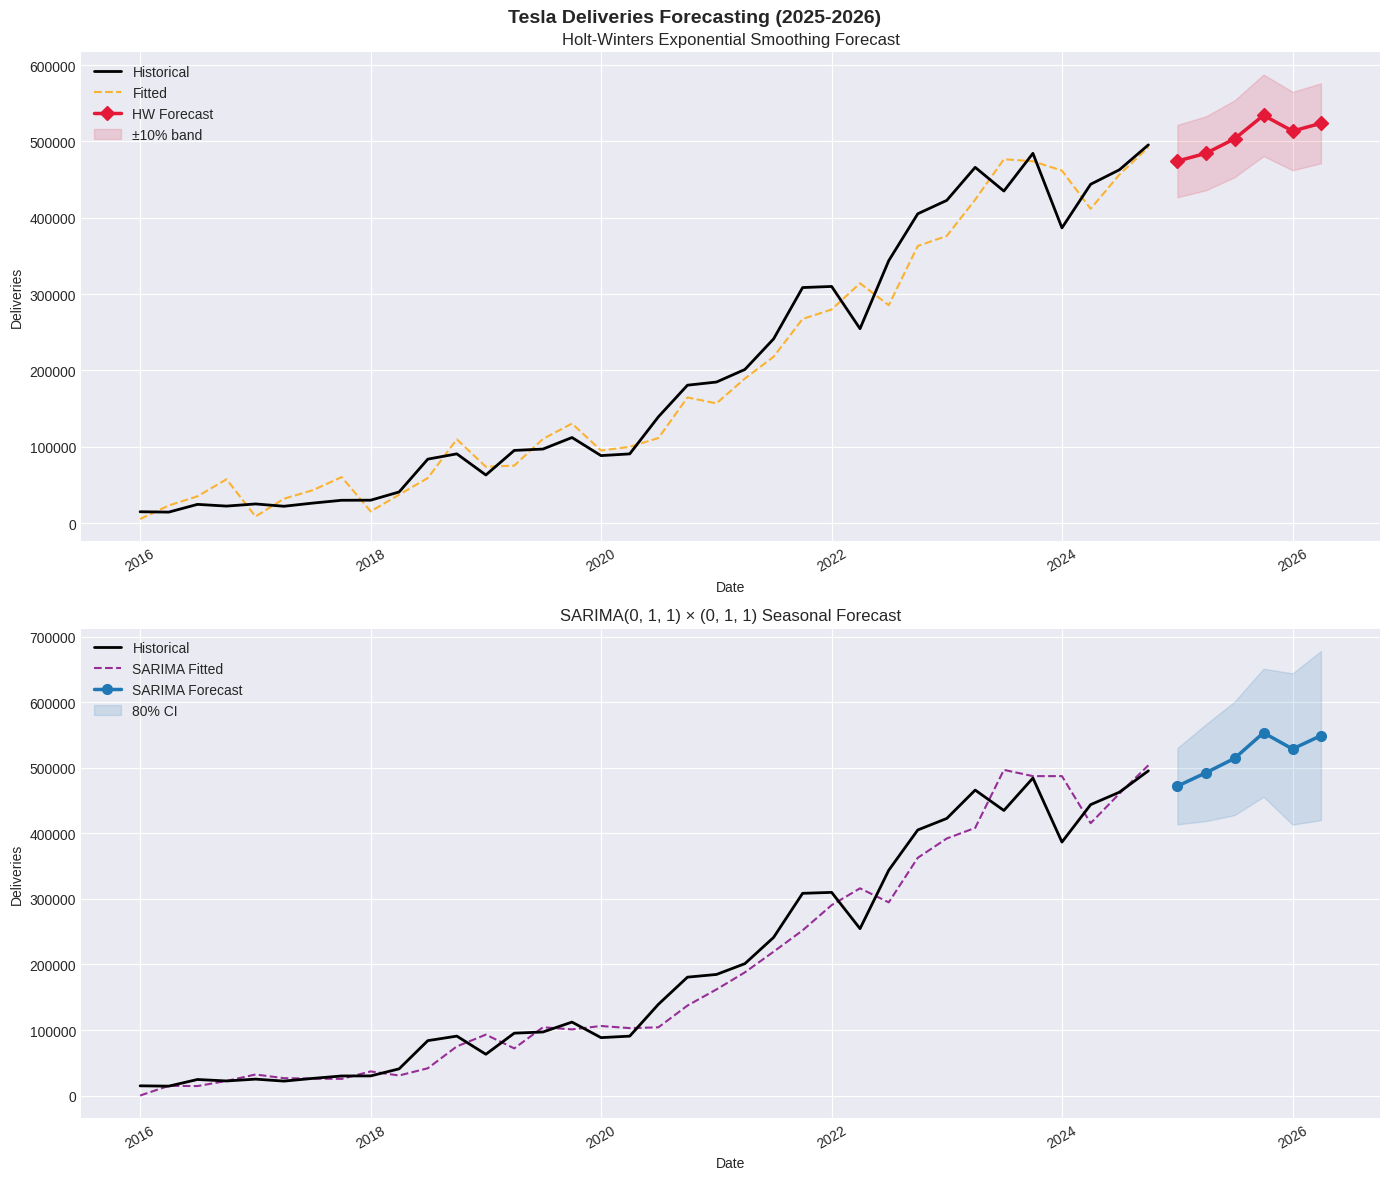

In [36]:
last_date=ts.index[-1]  # last date in our historical data
future_dates=pd.date_range(start=last_date+pd.DateOffset(months=3), periods=n_forecast, freq='QS')
# create future quarterly dates starting 3 months after the last data point

fig, axes=plt.subplots(2, 1, figsize=(14,12))  # 2 rows, 1 column
fig.suptitle('Tesla Deliveries Forecasting (2025-2026)', fontsize=14, fontweight='bold')  # big title

# --- Top chart: Holt-Winters ---
axes[0].plot(ts.index, ts.values, color='black', linewidth=2, label='Historical', zorder=3)  # historical data
axes[0].plot(ts.index, hw_fit.fittedvalues, color='orange', linewidth=1.5, linestyle='--', label='Fitted', alpha=0.8)
# fitted values show how well the model tracked historical data in-sample
axes[0].plot(future_dates, hw_forecast.values, color='#E31937', linewidth=2.5, marker='D',
             markersize=7, label='HW Forecast', zorder=3)  # forecast line in red
hw_upper=hw_forecast.values*1.10  # upper band = 10% above forecast
hw_lower=hw_forecast.values*0.90  # lower band = 10% below forecast
axes[0].fill_between(future_dates, hw_lower, hw_upper, color='#E31937', alpha=0.15, label='±10% band')
# shaded band shows uncertainty around the forecast
axes[0].set_title('Holt-Winters Exponential Smoothing Forecast')  # chart title
axes[0].set_xlabel('Date')  # x-axis
axes[0].set_ylabel('Deliveries')  # y-axis
axes[0].legend()  # legend
axes[0].tick_params(axis='x', rotation=30)  # tilt x labels

# --- Bottom chart: SARIMA ---
axes[1].plot(ts.index, ts.values, color='black', linewidth=2, label='Historical', zorder=3)  # historical data
axes[1].plot(ts.index, best_sarima_model.fittedvalues, color='purple', linewidth=1.5,
             linestyle='--', label='SARIMA Fitted', alpha=0.8)  # SARIMA in-sample fit
axes[1].plot(future_dates, sarima_forecast.values, color='#1f77b4', linewidth=2.5,
             marker='o', markersize=7, label='SARIMA Forecast', zorder=3)  # SARIMA forecast
try:
    sarima_ci=best_sarima_model.get_forecast(steps=n_forecast).conf_int(alpha=0.2)  # 80% confidence interval
    axes[1].fill_between(future_dates, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                         color='#1f77b4', alpha=0.15, label='80% CI')  # shade the CI area
except:  # if CI calculation fails, just skip it
    pass
axes[1].set_title(f'SARIMA{best_sarima_params[:3]} × {best_sarima_params[3:]} Seasonal Forecast')  # title with params
axes[1].set_xlabel('Date')  # x-axis
axes[1].set_ylabel('Deliveries')  # y-axis
axes[1].legend()  # legend
axes[1].tick_params(axis='x', rotation=30)  # tilt x labels

plt.tight_layout()  # fix spacing
plt.show()  # display

### 7.5 Forecast Table

In [37]:
forecast_df=pd.DataFrame({  # build a neat table of both forecasts side by side
    'Quarter': [str(d.date()) for d in future_dates],  # date for each quarter
    'Holt_Winters': [int(v) for v in hw_forecast.values],  # HW forecast values
    'SARIMA': [int(v) for v in sarima_forecast.values],  # SARIMA forecast values
})
forecast_df['Avg_Forecast']=(forecast_df['Holt_Winters']+forecast_df['SARIMA'])//2  # average of both models
# averaging two models often gives a more robust forecast than using just one

print('Forecast Table (Next 6 Quarters):')  # header
print(forecast_df.to_string(index=False))  # print the table without row numbers

Forecast Table (Next 6 Quarters):
   Quarter  Holt_Winters  SARIMA  Avg_Forecast
2025-01-01        474338  472173        473255
2025-04-01        484481  492563        488522
2025-07-01        503486  514500        508993
2025-10-01        534284  553632        543958
2026-01-01        513672  528876        521274
2026-04-01        523815  549266        536540


### 7.6 Combined Forecast Comparison
Overlaying all forecast models and an ensemble average on one chart.

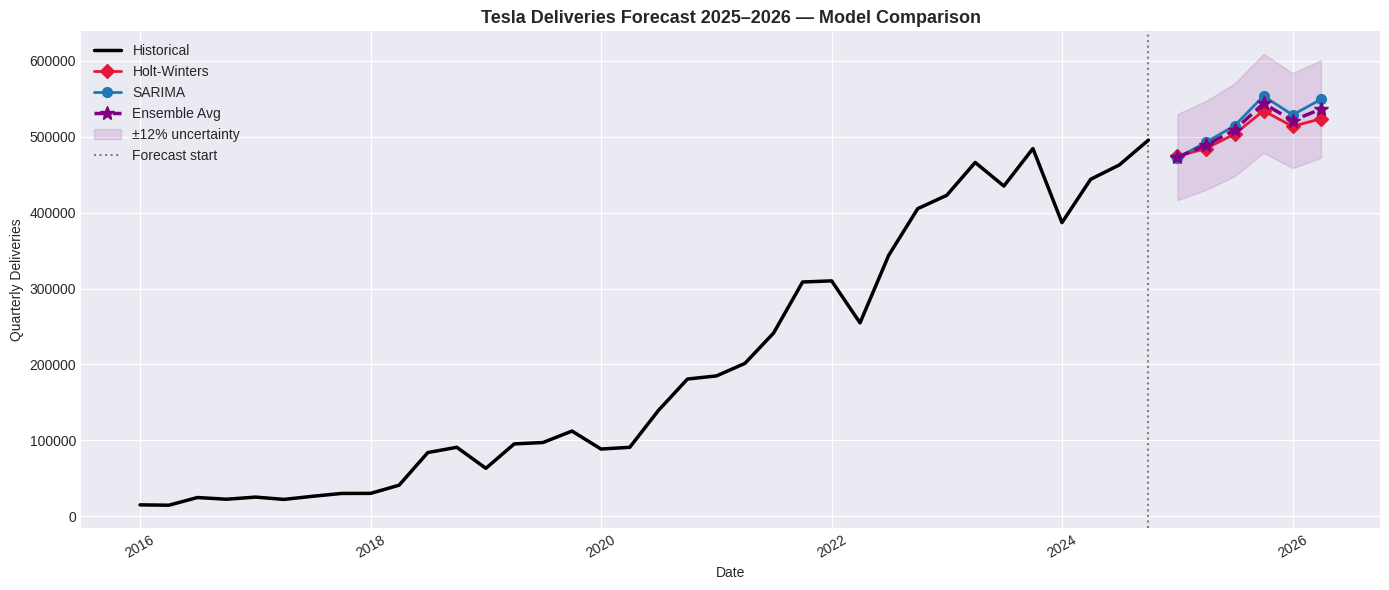

In [38]:
# ── 7.6  Combined Forecast Chart (HW + SARIMA + Ensemble) ──────────────────
ensemble_forecast = (hw_forecast.values + sarima_forecast.values) / 2

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts.index, ts.values, color='black', linewidth=2.5, label='Historical', zorder=4)

ax.plot(future_dates, hw_forecast.values,    color='#E31937',  linewidth=2,
        marker='D', markersize=7, label='Holt-Winters')
ax.plot(future_dates, sarima_forecast.values, color='#1f77b4',  linewidth=2,
        marker='o', markersize=7, label='SARIMA')
ax.plot(future_dates, ensemble_forecast,      color='purple',    linewidth=2.5,
        marker='*', markersize=10, label='Ensemble Avg', zorder=5, linestyle='--')

# shade the uncertainty band around ensemble
upper = ensemble_forecast * 1.12
lower = ensemble_forecast * 0.88
ax.fill_between(future_dates, lower, upper, color='purple', alpha=0.12, label='±12% uncertainty')

ax.axvline(x=ts.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Forecast start')
ax.set_title('Tesla Deliveries Forecast 2025–2026 — Model Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Quarterly Deliveries')
ax.legend(loc='upper left')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 7.7 Walk-Forward Back-Test
Back-testing the Holt-Winters model on the last 8 quarters to measure real forecast accuracy.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be use

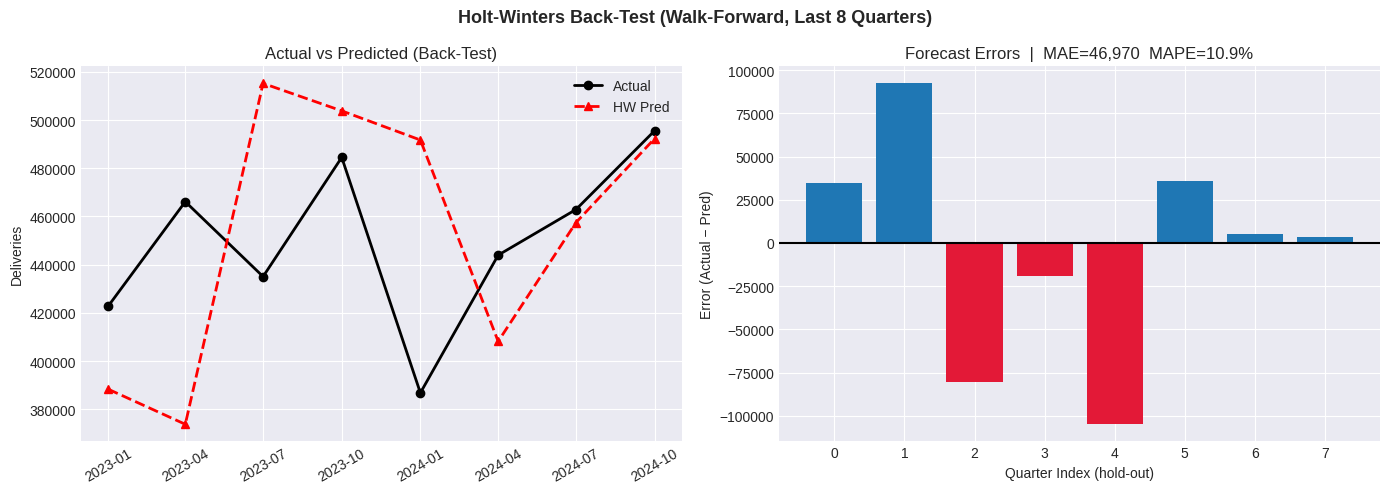

Back-test MAE : 46,970 units
Back-test MAPE: 10.9%


In [39]:
# ── 7.7  Forecast Back-Test (Walk-Forward Validation) ──────────────────────
# Use last 8 quarters as hold-out; train on preceding data → forecast 1 step
backtest_results = []
for end_idx in range(len(ts) - 8, len(ts)):
    train_ts = ts.iloc[:end_idx]
    actual   = ts.iloc[end_idx]
    try:
        hw_bt = ExponentialSmoothing(train_ts, trend='add', seasonal='add',
                                      seasonal_periods=4,
                                      initialization_method='estimated').fit(optimized=True)
        pred = hw_bt.forecast(1).iloc[0]
    except Exception:
        pred = train_ts.iloc[-1]   # fallback: naive last value
    backtest_results.append({
        'Date':    ts.index[end_idx],
        'Actual':  actual,
        'HW_Pred': pred,
        'Error':   actual - pred
    })

bt_df = pd.DataFrame(backtest_results)
bt_mae  = bt_df['Error'].abs().mean()
bt_mape = (bt_df['Error'].abs() / bt_df['Actual']).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Holt-Winters Back-Test (Walk-Forward, Last 8 Quarters)', fontsize=13, fontweight='bold')

axes[0].plot(bt_df['Date'], bt_df['Actual'],  'ko-', label='Actual',    linewidth=2)
axes[0].plot(bt_df['Date'], bt_df['HW_Pred'], 'r^--', label='HW Pred', linewidth=2)
axes[0].set_title('Actual vs Predicted (Back-Test)')
axes[0].set_ylabel('Deliveries')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(range(len(bt_df)), bt_df['Error'], color=['#E31937' if e<0 else '#1f77b4' for e in bt_df['Error']])
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_title(f'Forecast Errors  |  MAE={bt_mae:,.0f}  MAPE={bt_mape:.1f}%')
axes[1].set_xlabel('Quarter Index (hold-out)')
axes[1].set_ylabel('Error (Actual − Pred)')

plt.tight_layout()
plt.show()
print(f"Back-test MAE : {bt_mae:,.0f} units")
print(f"Back-test MAPE: {bt_mape:.1f}%")


---
## ✅ Final Summary

In [41]:
# ── ✅  Enhanced Final Summary ──────────────────────────────────────────────
print('='*70)
print('  ENHANCED PIPELINE COMPLETE — FULL SUMMARY')
print('='*70)

print(f'\n Dataset: Tesla Deliveries & Production (2015–2024)')
print(f'   Total quarters after feature engineering: {len(df)}')
print(f'   Features used in modelling             : {len(feature_cols)}')

print('\n All Regression Results (Test Set) — sorted by R²:')
all_res = {**results}
for name, res in sorted(all_res.items(), key=lambda x: x[1]['R2'], reverse=True):
    print(f'   {name:<28} R²={res["R2"]:.4f}  RMSE={res["RMSE"]:>9,.0f}  MAE={res["MAE"]:>9,.0f}')

print(f'\n Best model by RMSE: {min(all_res, key=lambda x: all_res[x]["RMSE"])}')
print(f'   Tuned RF — RMSE: {tuned_rmse:,.0f}  |  R²: {tuned_r2:.4f}')

print(f'\n Cross-Validation (5-Fold) Summary:')
for name, scores in cv_summary.items():
    print(f'   {name:<28} CV-RMSE: {scores.mean():>9,.0f} ± {scores.std():>7,.0f}')

print(f'\n 6-Quarter Forecast (2025–2026):')
print(f'   {"Quarter":<15} {"Holt-Winters":>14} {"SARIMA":>12} {"Ensemble":>12}')
for _, row in forecast_df.iterrows():
    ens = (row["Holt_Winters"] + row["SARIMA"]) // 2
    print(f'   {row["Quarter"]:<15} {row["Holt_Winters"]:>14,} {row["SARIMA"]:>12,} {ens:>12,}')

print(f'\n Back-Test (Hold-Out 8 Quarters):')
print(f'   MAE : {bt_mae:,.0f} units  |  MAPE: {bt_mape:.1f}%')

print('\n End-to-end ML pipeline (enhanced) completed successfully!')


  ENHANCED PIPELINE COMPLETE — FULL SUMMARY

 Dataset: Tesla Deliveries & Production (2015–2024)
   Total quarters after feature engineering: 36
   Features used in modelling             : 15

 All Regression Results (Test Set) — sorted by R²:
   Linear Regression            R²=1.0000  RMSE=        0  MAE=        0
   Lasso Regression             R²=1.0000  RMSE=      581  MAE=      420
   Ridge Regression             R²=0.9961  RMSE=   10,848  MAE=    8,765
   Gradient Boosting            R²=0.9892  RMSE=   17,977  MAE=   14,267
   XGBoost                      R²=0.9857  RMSE=   20,742  MAE=   18,066
   ElasticNet                   R²=0.9785  RMSE=   25,438  MAE=   22,115
   Random Forest                R²=0.9722  RMSE=   28,910  MAE=   21,893
   Poly Ridge (deg=2)           R²=0.9518  RMSE=   38,045  MAE=   31,611

 Best model by RMSE: Linear Regression
   Tuned RF — RMSE: 27,533  |  R²: 0.9748

 Cross-Validation (5-Fold) Summary:
   Linear Regression            CV-RMSE:         0 ± 